##Install Dependencies

In [ ]:
!pip install gymnasium[atari] ale-py autorom torch torchvision opencv-python
!AutoROM --accept-license

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/adventure.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/air_raid.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/alien.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/amidar.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/assault.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asterix.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asteroids.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis2.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/backgammon.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/bank_heist.bin
Inst

##Register Atari Environment

In [ ]:
import gymnasium as gym
import torch.nn as nn
import ale_py

gym.register_envs(ale_py)

##Test Environment

In [ ]:
env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
obs, _ = env.reset()
print(obs.shape)

(210, 160, 3)


##Preprocessing Wrapper

In [ ]:
import cv2
import numpy as np
from collections import deque

class AtariPreprocessing:
    def __init__(self, env):
        self.env = env
        self.frames = deque(maxlen=4)

        # forward attributes
        self.action_space = env.action_space
        self.observation_space = env.observation_space

    def reset(self, **kwargs):
      obs, info = self.env.reset(**kwargs)
      frame = self.process(obs)
      self.frames.clear()
      for _ in range(4):
        self.frames.append(frame)

      return np.stack(self.frames, axis=0), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        frame = self.process(obs)
        self.frames.append(frame)

        return np.stack(self.frames, axis=0), reward, terminated, truncated, info

    def process(self, frame):
        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
        frame = cv2.resize(frame, (84, 84))
        return frame

##Wrap Environment

In [ ]:
env = gym.make("ALE/Breakout-v5")
env = AtariPreprocessing(env)

state = env.reset()
print(state) # test

(array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], dtype=uint8), {'lives': 5, 'episode_frame_number': 0, 'frame_number': 0})


##DQN Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class DQN(nn.Module):
    def __init__(self, action_size):
        super(DQN, self).__init__()

        self.conv1 = nn.Conv2d(4, 16, kernel_size=8, stride=4)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=4, stride=2)

        self.fc1 = nn.Linear(32 * 9 * 9, 256)
        self.fc2 = nn.Linear(256, action_size)

    def forward(self, x):
        x = x / 255.0
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

##Replay Buffers

In [ ]:
import random
import numpy as np
from collections import deque


class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*batch)

        return (
            np.array(state),
            np.array(action),
            np.array(reward),
            np.array(next_state),
            np.array(done),
        )

    def __len__(self):
        return len(self.buffer)


##Train

In [ ]:
import gymnasium as gym
import torch
import torch.optim as optim
import numpy as np


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

env = gym.make("ALE/Breakout-v5")
env = AtariPreprocessing(env)

action_size = env.action_space.n

q_net = DQN(action_size).to(DEVICE)
target_net = DQN(action_size).to(DEVICE)
target_net.load_state_dict(q_net.state_dict())

optimizer = optim.Adam(q_net.parameters(), lr=1e-4)
buffer = ReplayBuffer(100000)

GAMMA = 0.99
BATCH_SIZE = 32
EPSILON = 1.0
EPSILON_MIN = 0.1
EPSILON_DECAY = 1e-6

UPDATE_TARGET_EVERY = 1000
STEPS = 0

state, _ = env.reset()
env.step(1)
episode_rewards = []
losses = []

for episode in range(500):
    state, _ = env.reset()
    total_reward = 0

    for t in range(10000):
        STEPS += 1

        if np.random.rand() < EPSILON:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                s = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(DEVICE)
                action = q_net(s).argmax().item()

        next_state, reward, done, truncated, _ = env.step(action)
        reward = np.sign(reward)


        buffer.push(state, action, reward, next_state, done)

        state = next_state
        total_reward += reward

        if len(buffer) > BATCH_SIZE:
            s, a, r, s_next, d = buffer.sample(BATCH_SIZE)

            s = torch.tensor(s, dtype=torch.float32).to(DEVICE)
            a = torch.tensor(a).to(DEVICE)
            r = torch.tensor(r, dtype=torch.float32).to(DEVICE)
            s_next = torch.tensor(s_next, dtype=torch.float32).to(DEVICE)
            d = torch.tensor(d, dtype=torch.float32).to(DEVICE)  # FIX

            q_values = q_net(s).gather(1, a.unsqueeze(1)).squeeze()

            with torch.no_grad():
                next_q = target_net(s_next).max(1)[0]
                target = r + GAMMA * next_q * (1 - d)

            loss = (q_values - target).pow(2).mean()
            loss1 = nn.MSELoss()(q_values, target.detach())
            losses.append(loss1.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if STEPS % UPDATE_TARGET_EVERY == 0:
            target_net.load_state_dict(q_net.state_dict())

        EPSILON = max(EPSILON_MIN, EPSILON - EPSILON_DECAY)

        if done or truncated:
            break
    episode_rewards.append(total_reward)
    print(f"Episode: {episode}, Reward: {total_reward}, Epsilon: {EPSILON:.3f}")


Episode: 0, Reward: 1.0, Epsilon: 1.000
Episode: 1, Reward: 4.0, Epsilon: 1.000
Episode: 2, Reward: 0.0, Epsilon: 0.999
Episode: 3, Reward: 1.0, Epsilon: 0.999
Episode: 4, Reward: 3.0, Epsilon: 0.999
Episode: 5, Reward: 1.0, Epsilon: 0.999
Episode: 6, Reward: 2.0, Epsilon: 0.999
Episode: 7, Reward: 2.0, Epsilon: 0.998
Episode: 8, Reward: 2.0, Epsilon: 0.998
Episode: 9, Reward: 1.0, Epsilon: 0.998
Episode: 10, Reward: 2.0, Epsilon: 0.998
Episode: 11, Reward: 0.0, Epsilon: 0.998
Episode: 12, Reward: 1.0, Epsilon: 0.997
Episode: 13, Reward: 3.0, Epsilon: 0.997
Episode: 14, Reward: 0.0, Epsilon: 0.997
Episode: 15, Reward: 1.0, Epsilon: 0.997
Episode: 16, Reward: 3.0, Epsilon: 0.997
Episode: 17, Reward: 2.0, Epsilon: 0.996
Episode: 18, Reward: 0.0, Epsilon: 0.996
Episode: 19, Reward: 2.0, Epsilon: 0.996
Episode: 20, Reward: 2.0, Epsilon: 0.996
Episode: 21, Reward: 0.0, Epsilon: 0.996
Episode: 22, Reward: 2.0, Epsilon: 0.995
Episode: 23, Reward: 0.0, Epsilon: 0.995
Episode: 24, Reward: 0.0, 

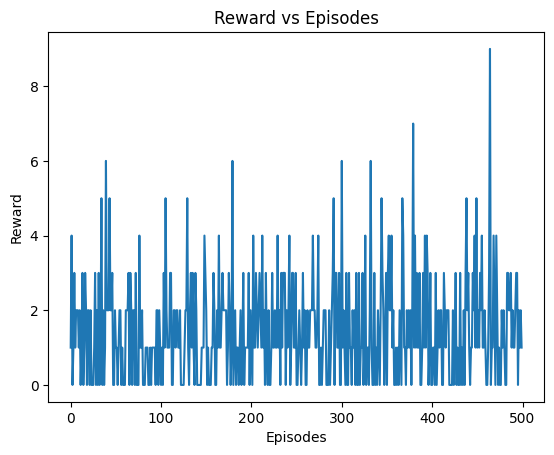

In [ ]:
import matplotlib.pyplot as plt

plt.plot(episode_rewards)
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Reward vs Episodes")
plt.show()

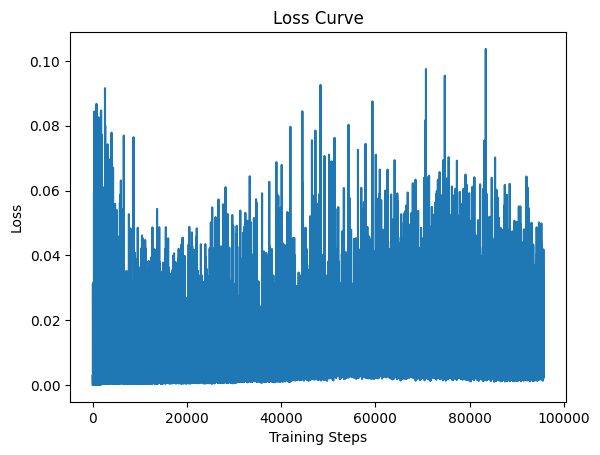

In [ ]:
plt.plot(losses)
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.show()

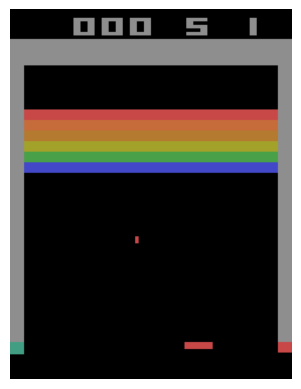

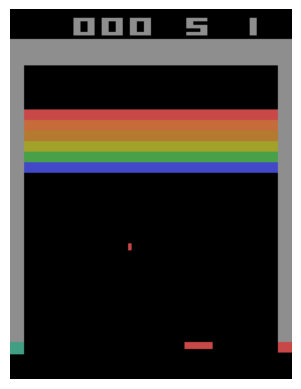

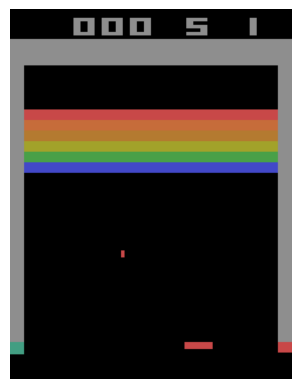

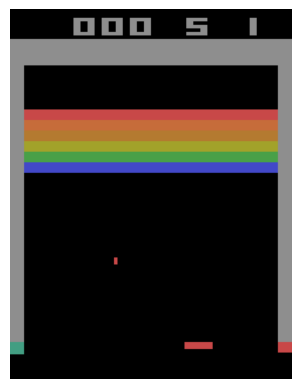

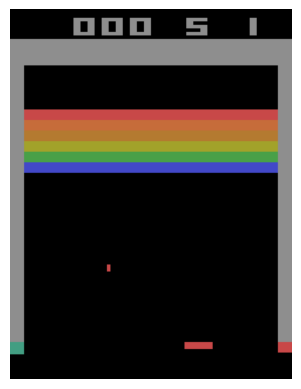

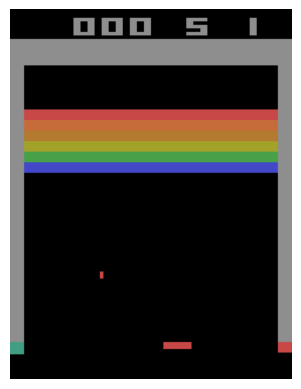

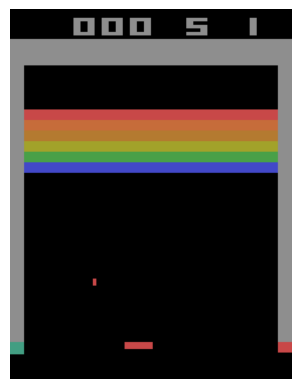

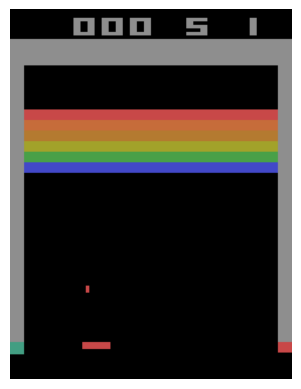

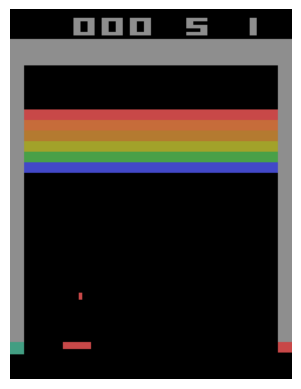

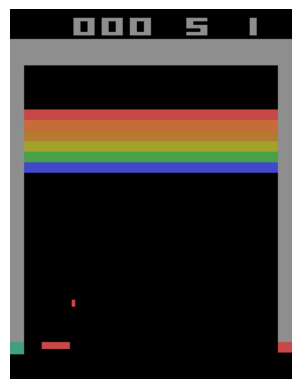

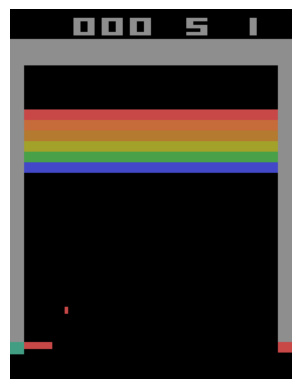

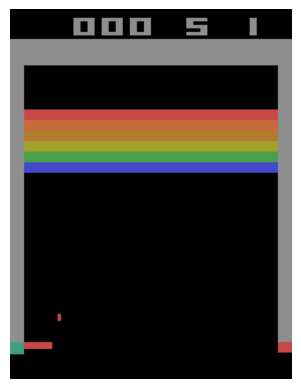

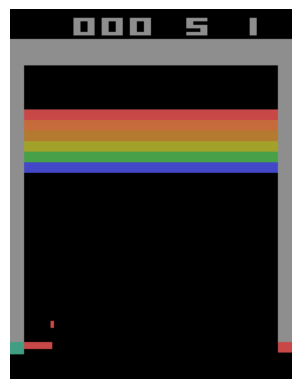

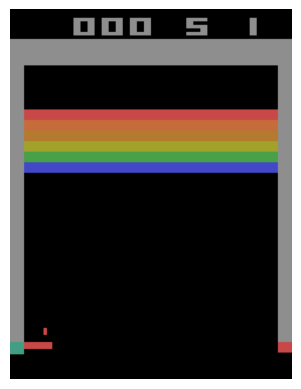

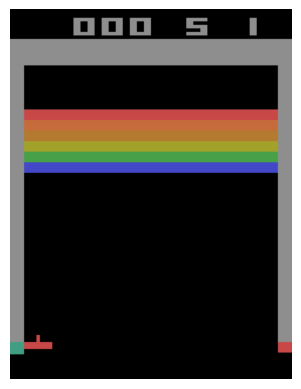

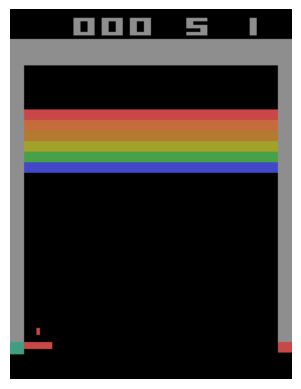

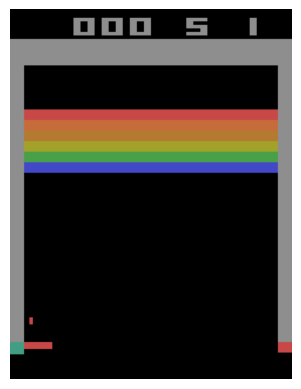

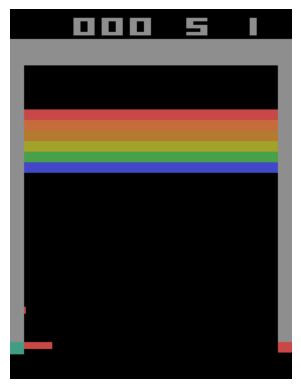

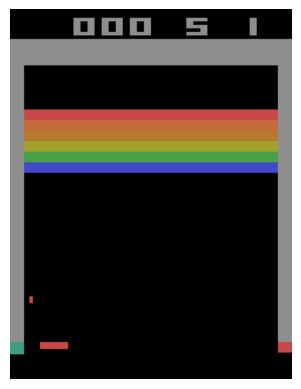

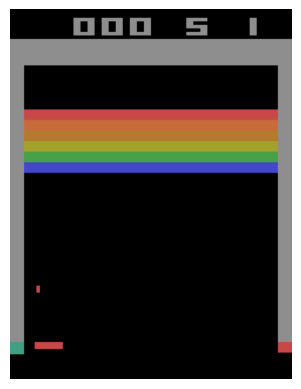

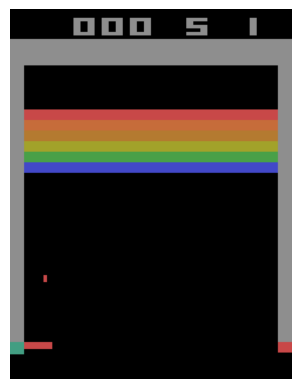

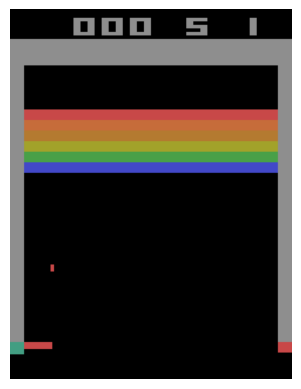

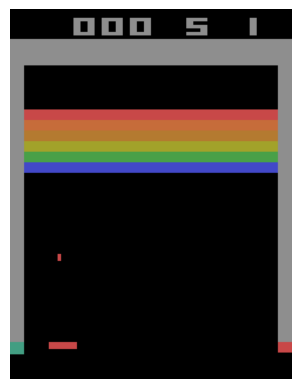

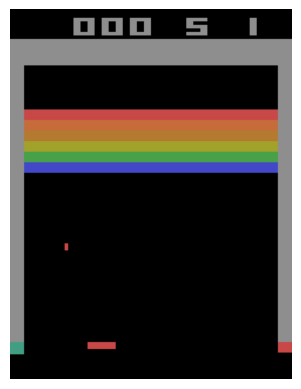

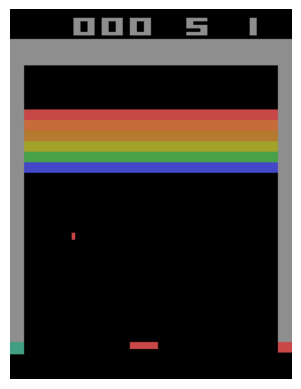

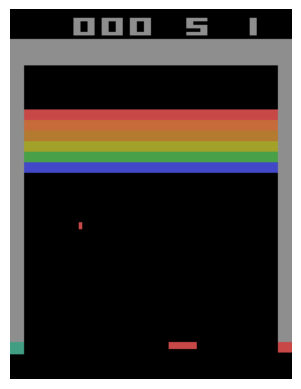

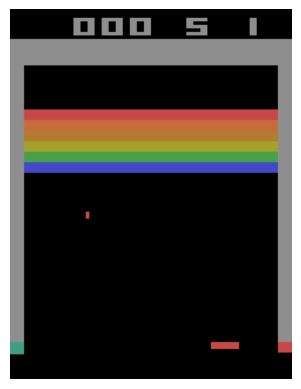

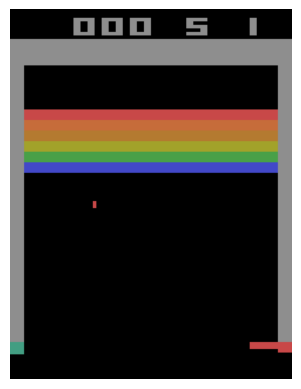

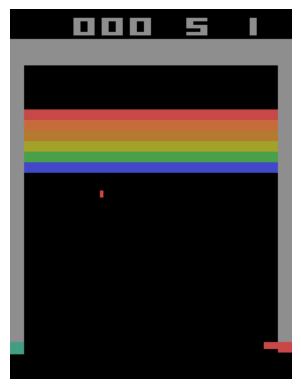

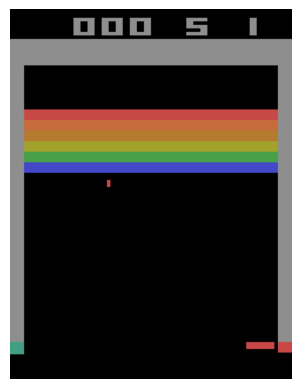

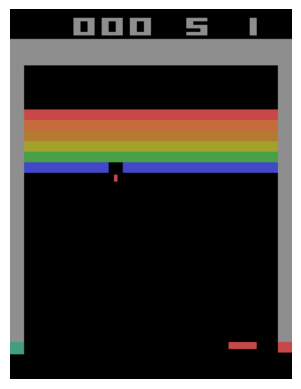

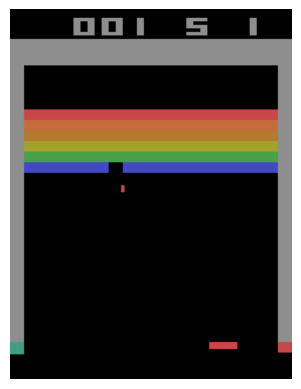

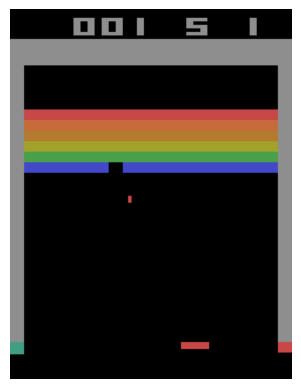

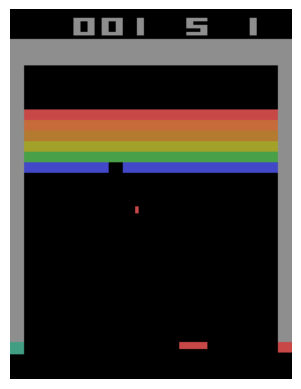

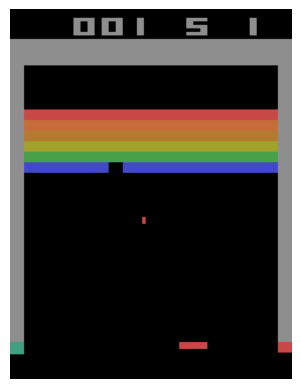

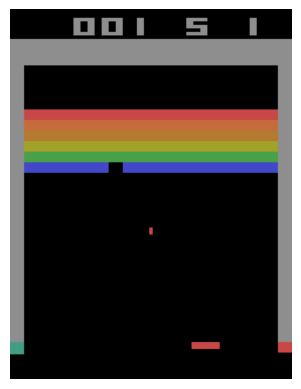

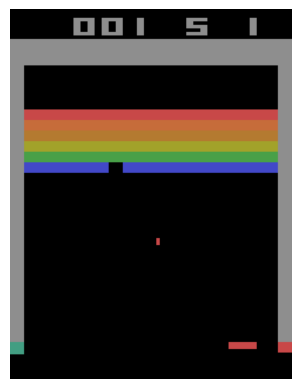

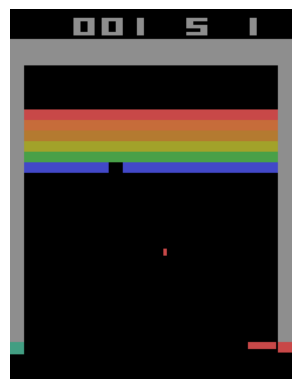

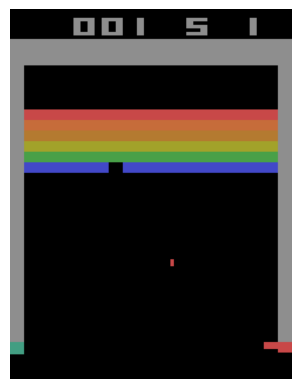

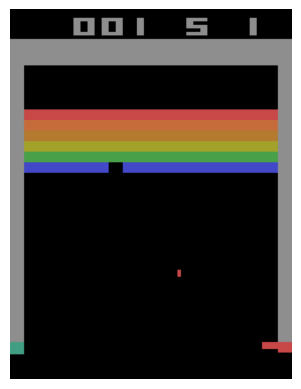

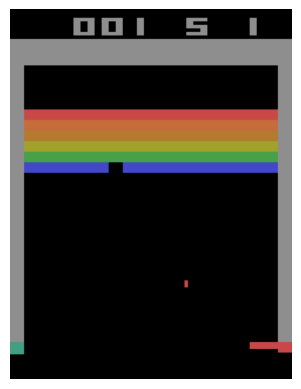

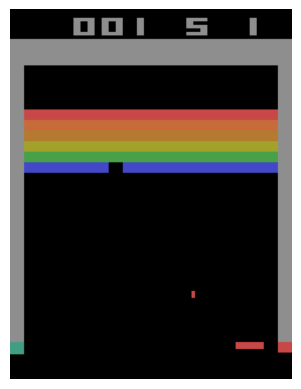

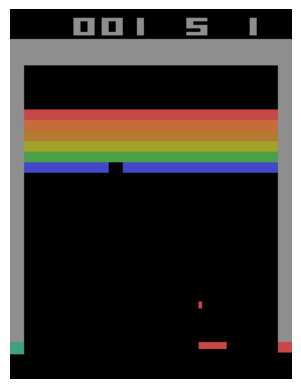

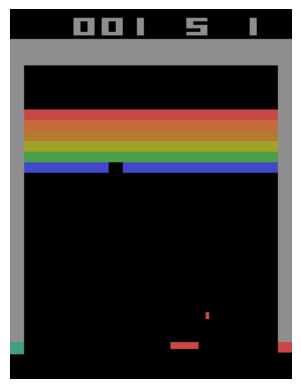

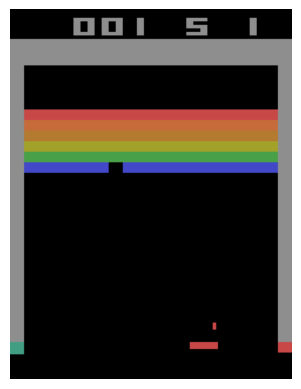

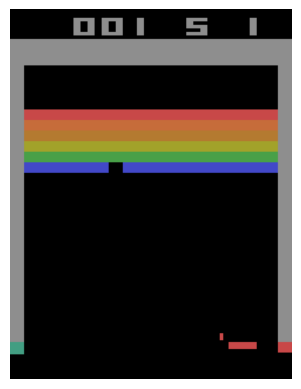

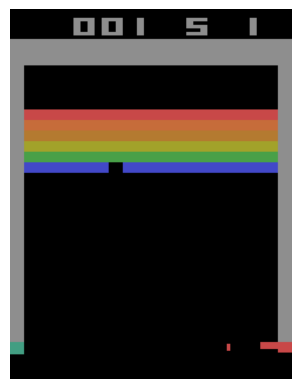

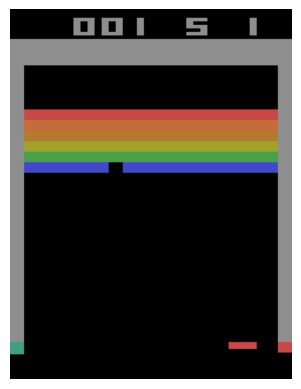

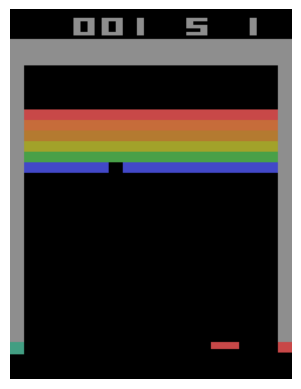

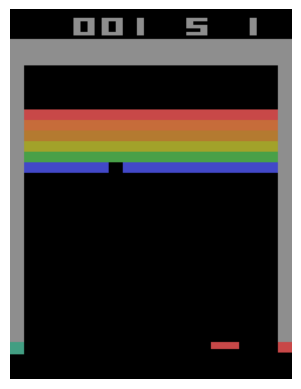

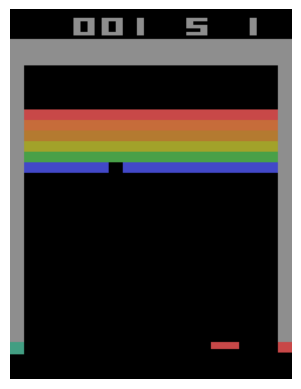

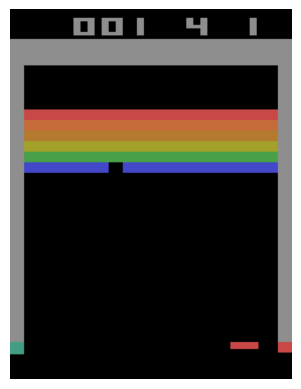

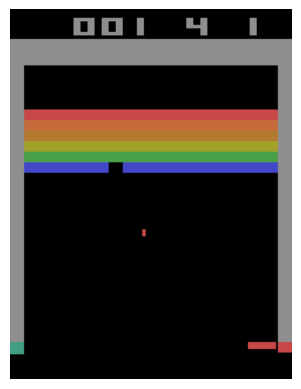

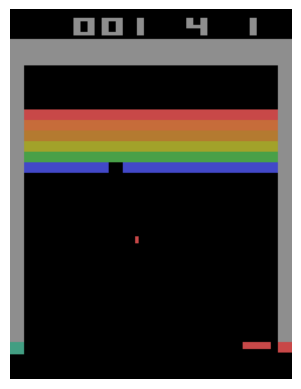

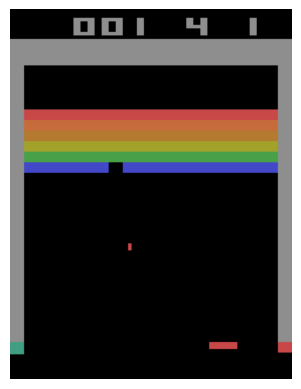

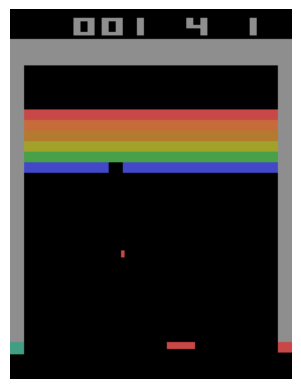

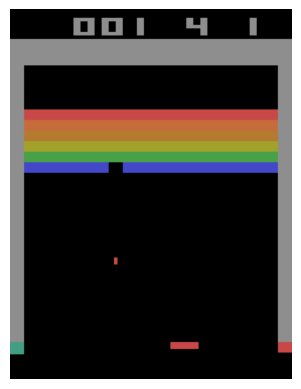

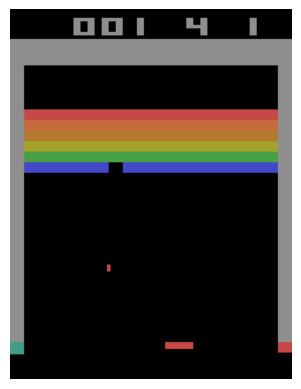

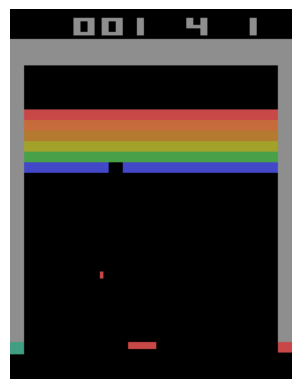

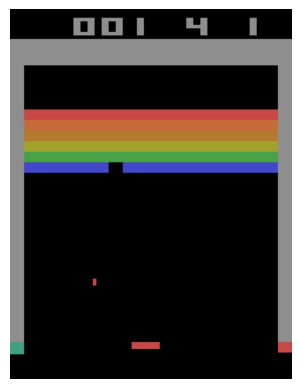

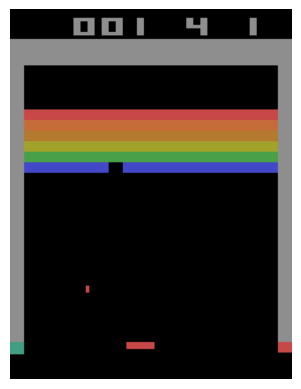

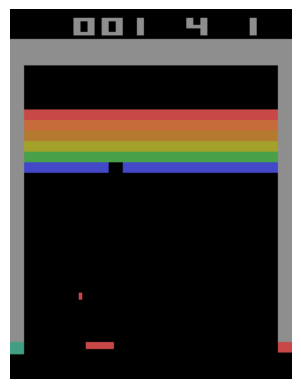

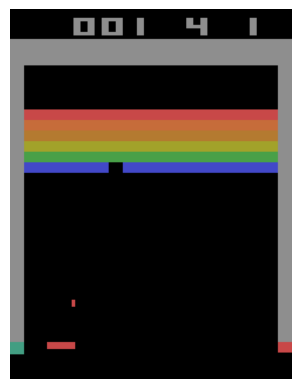

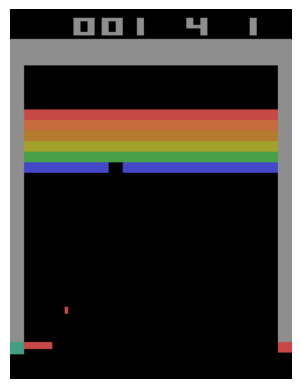

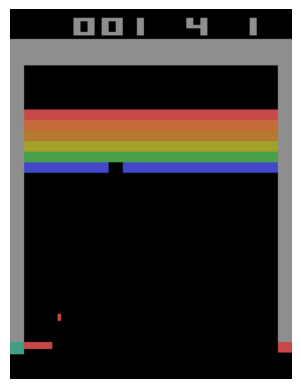

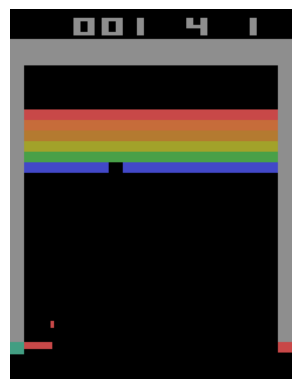

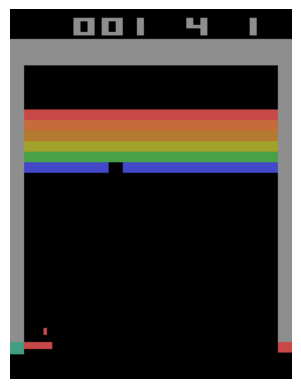

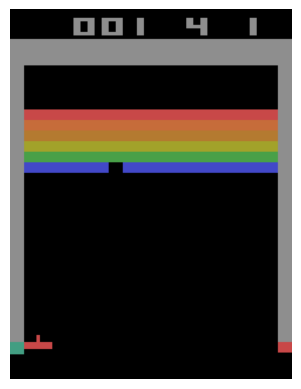

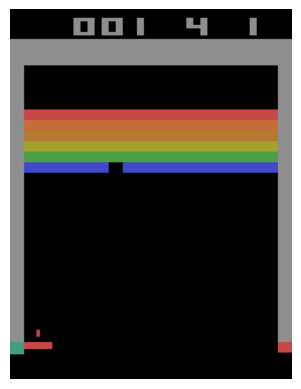

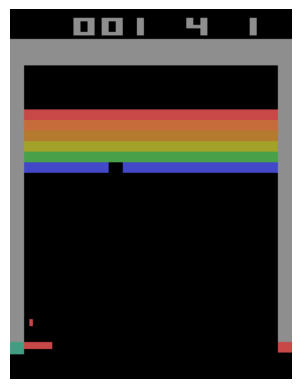

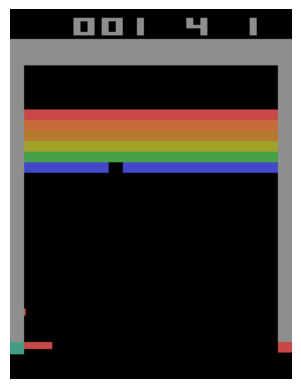

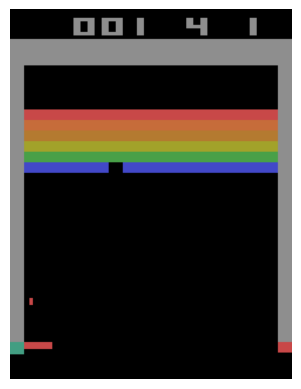

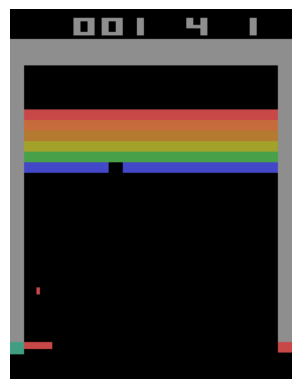

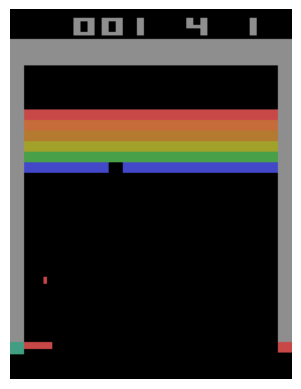

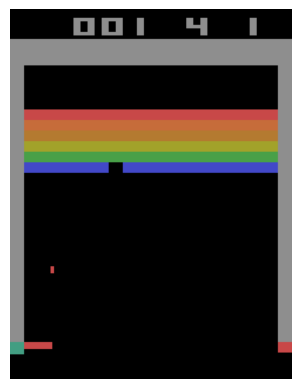

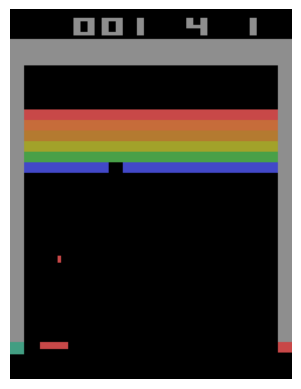

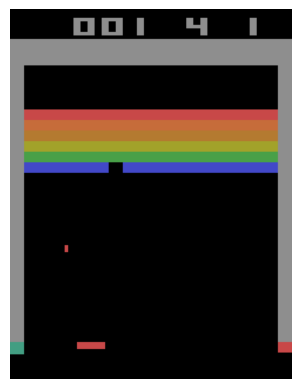

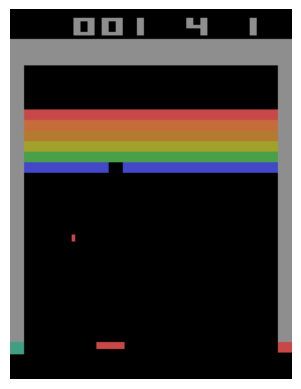

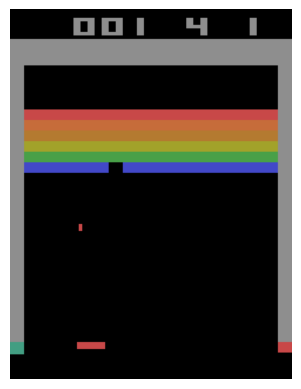

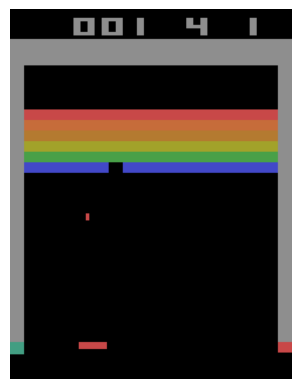

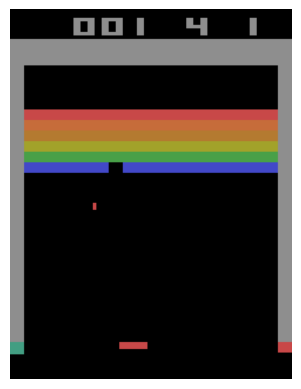

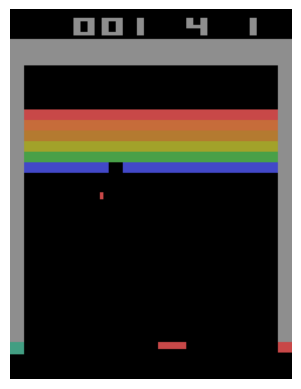

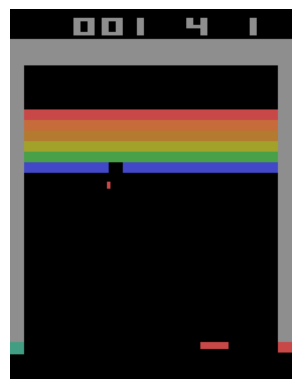

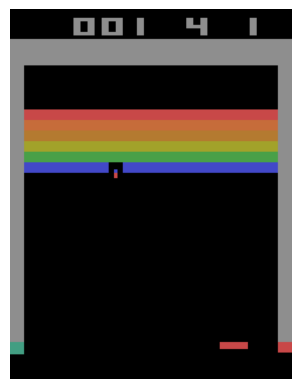

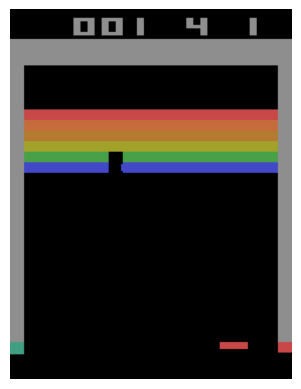

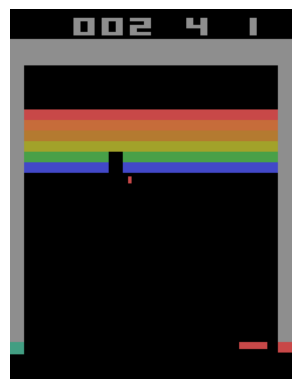

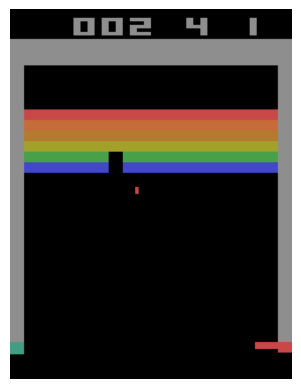

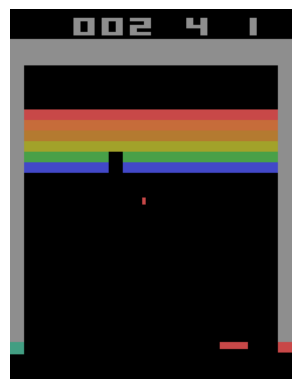

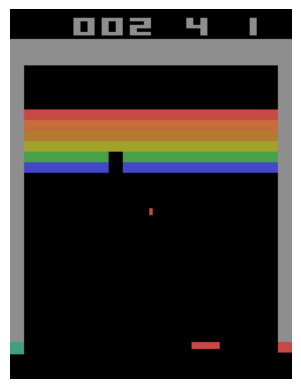

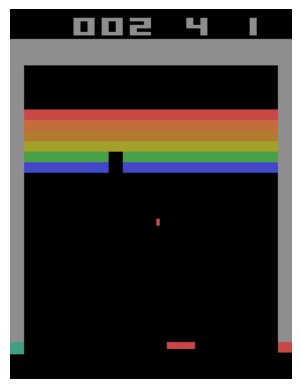

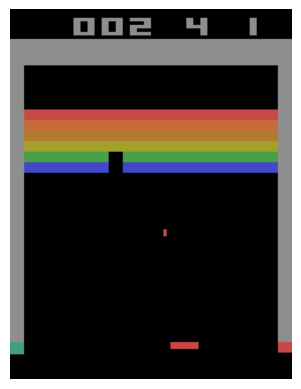

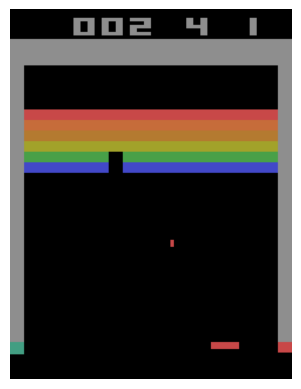

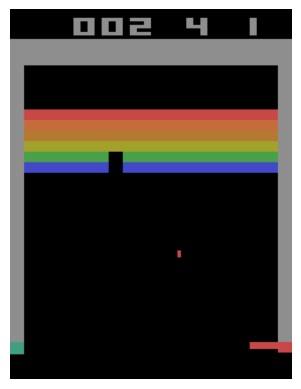

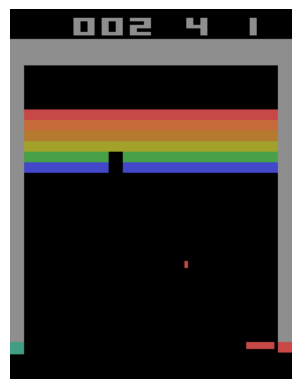

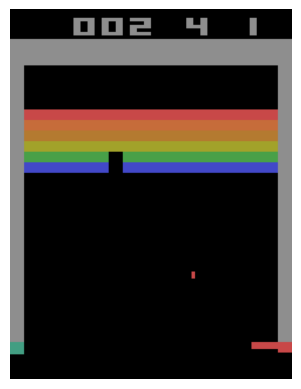

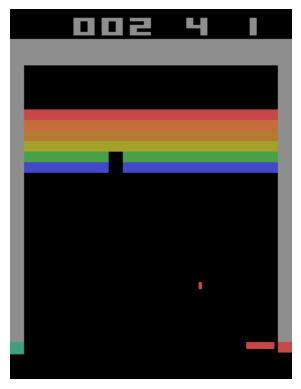

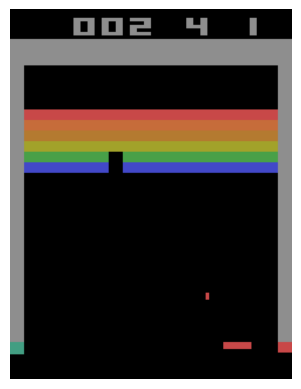

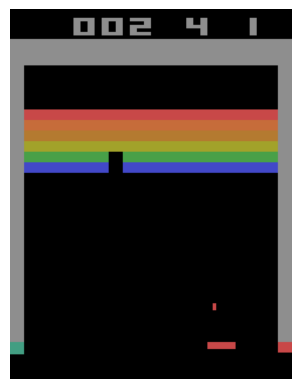

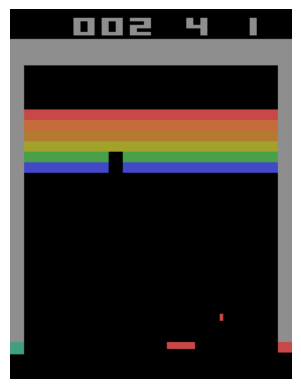

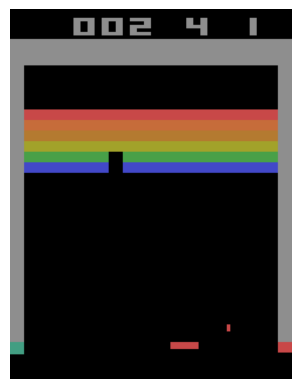

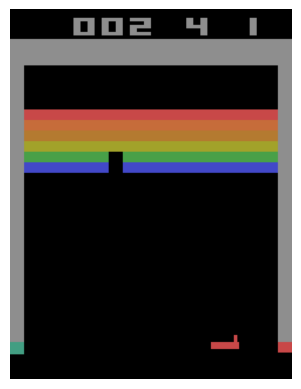

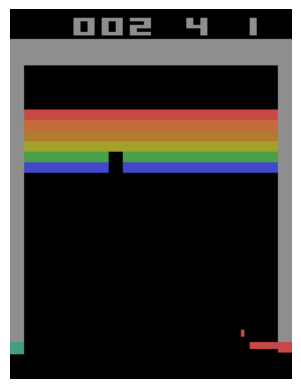

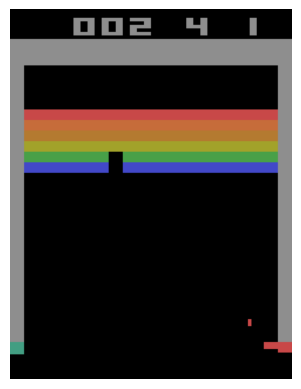

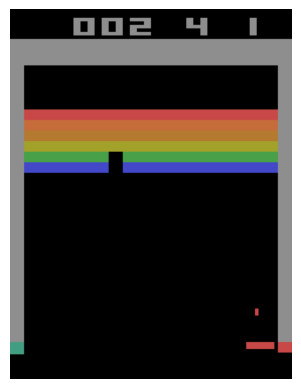

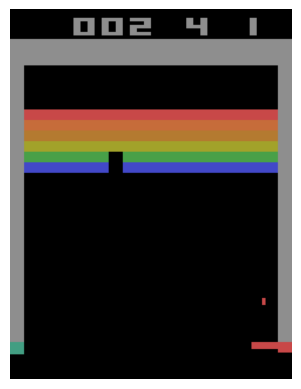

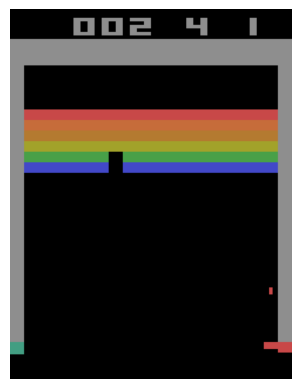

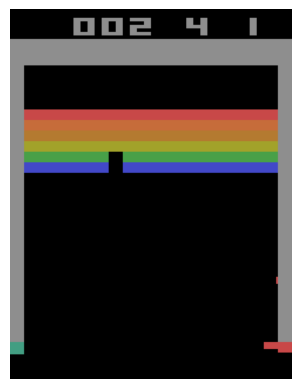

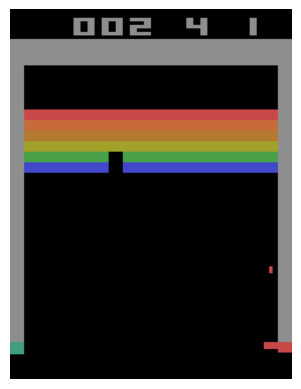

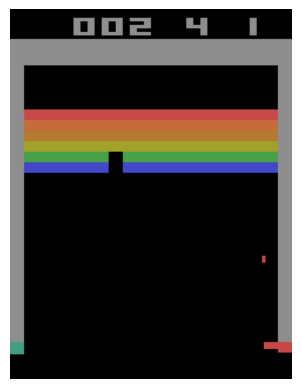

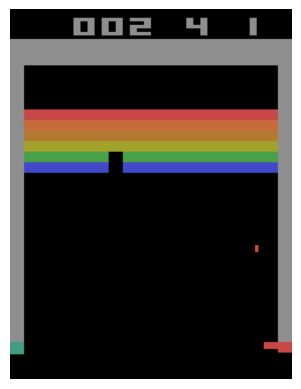

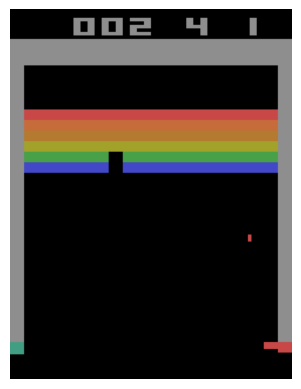

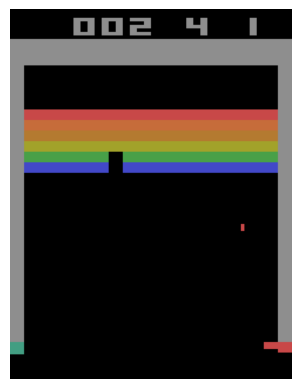

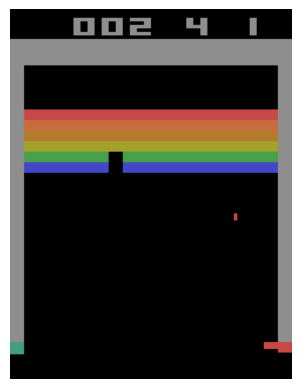

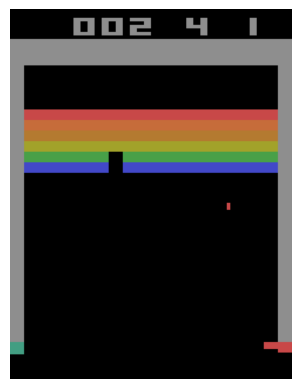

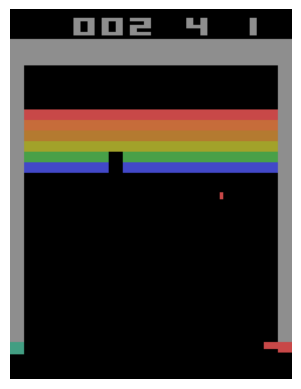

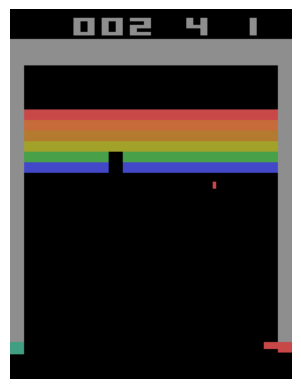

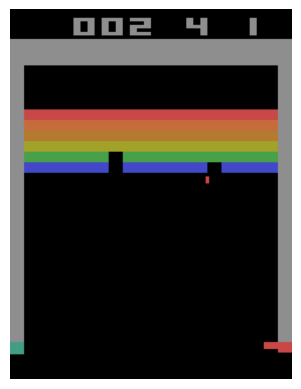

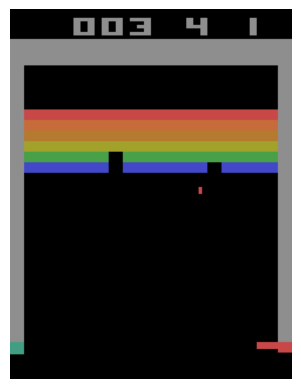

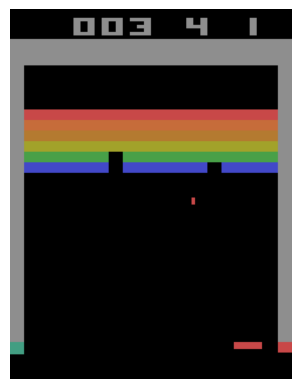

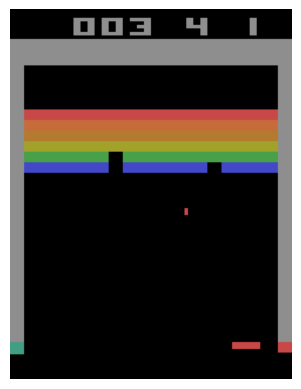

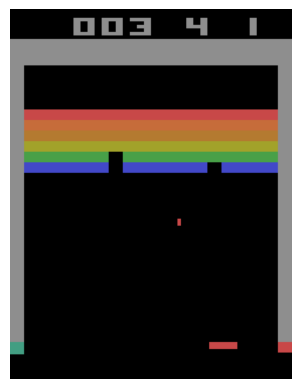

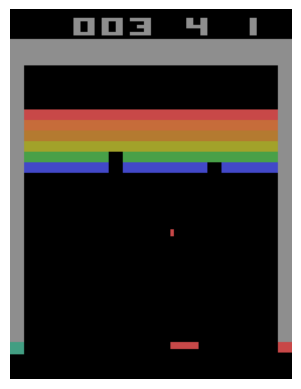

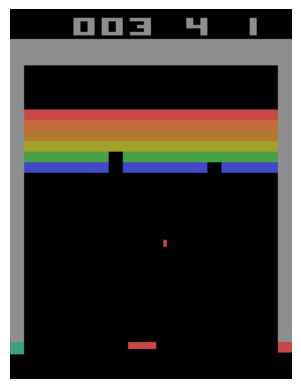

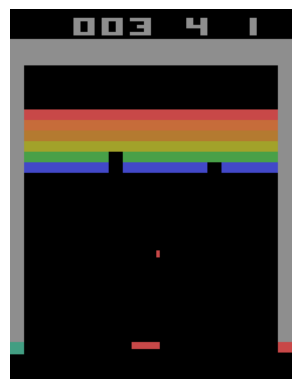

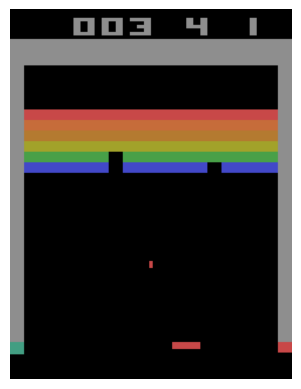

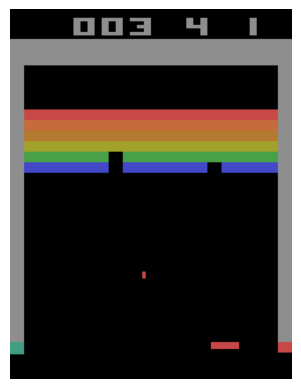

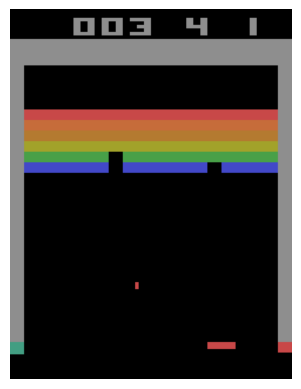

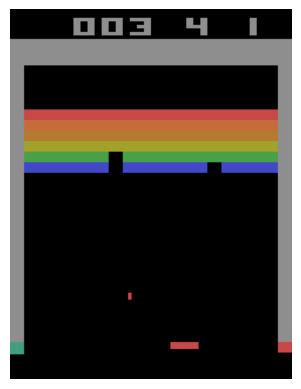

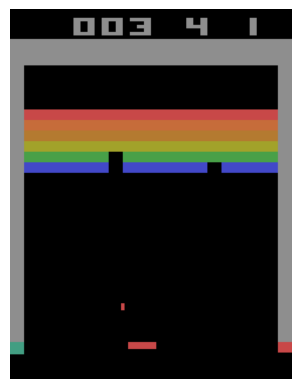

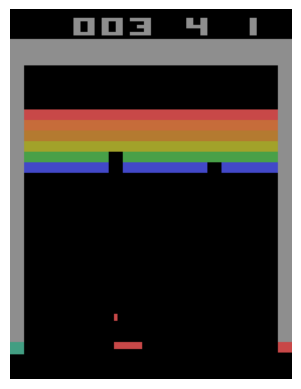

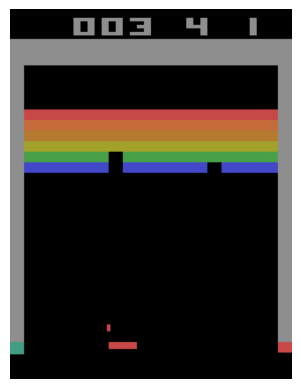

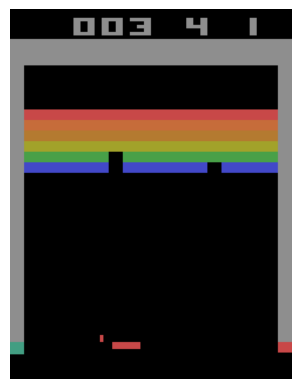

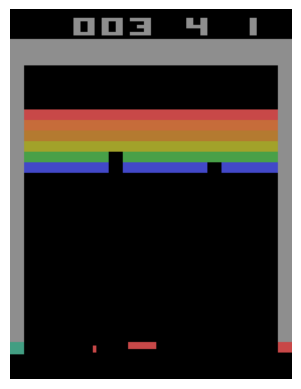

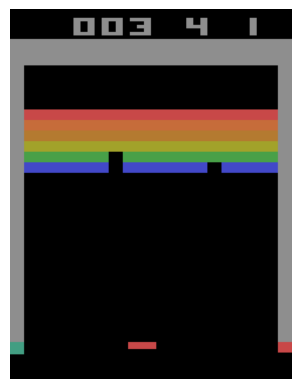

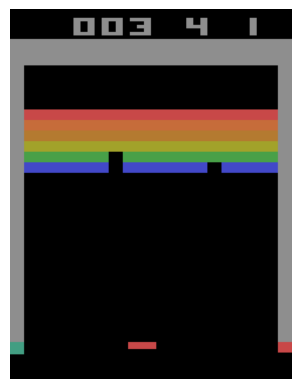

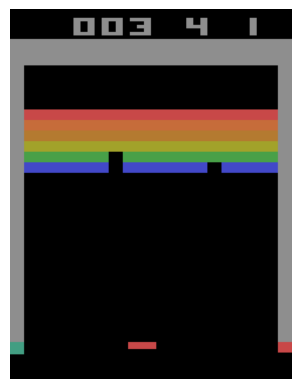

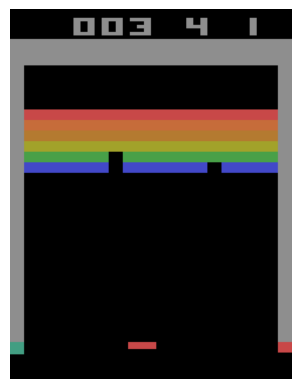

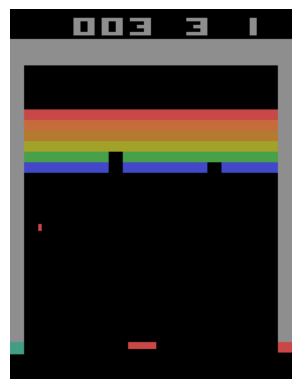

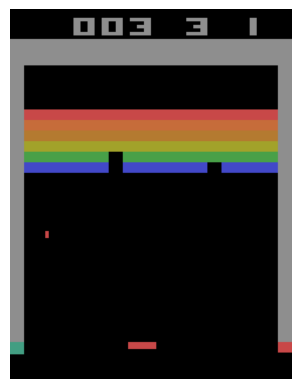

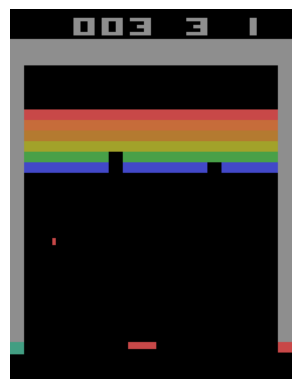

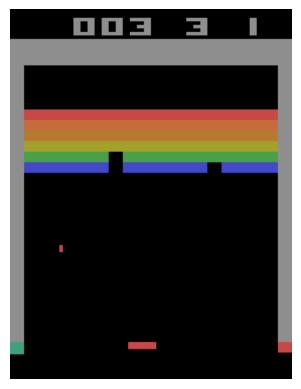

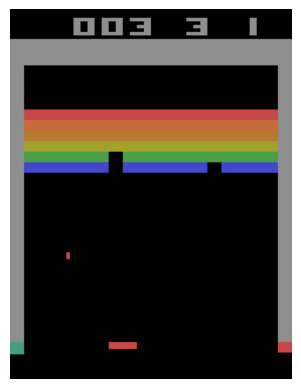

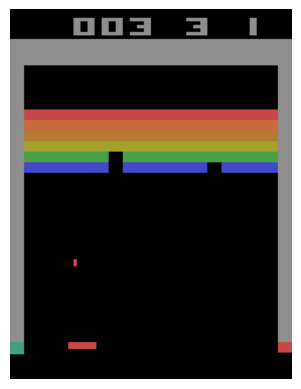

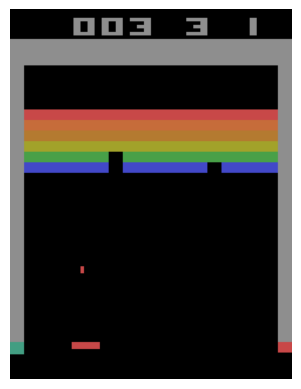

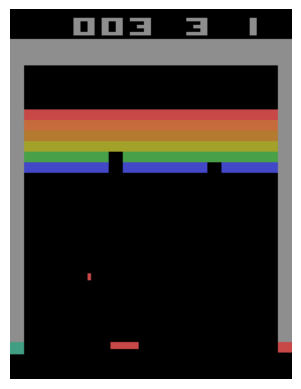

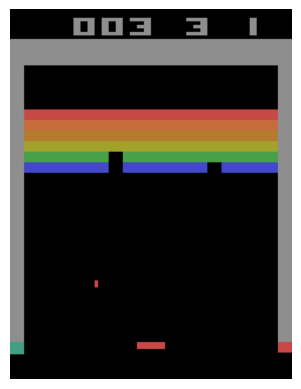

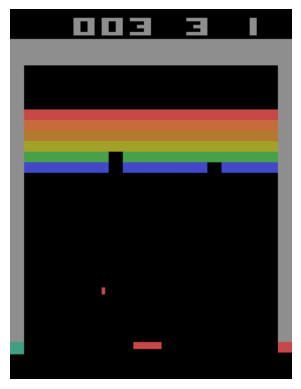

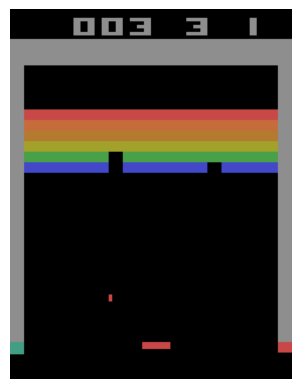

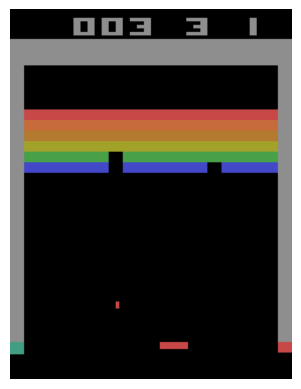

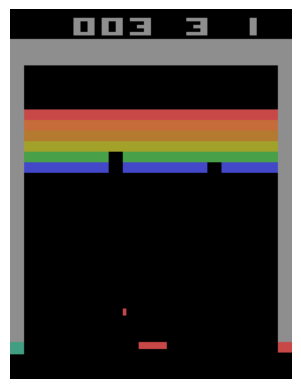

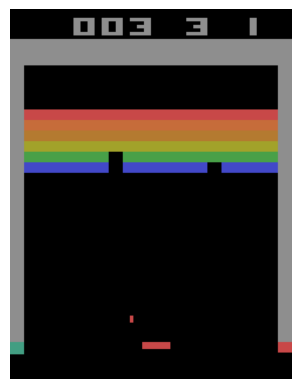

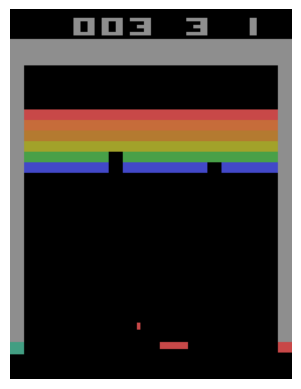

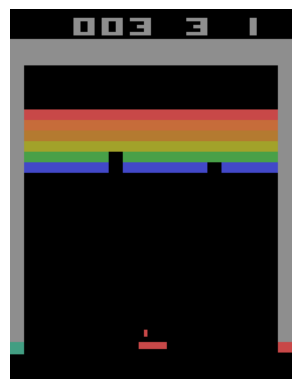

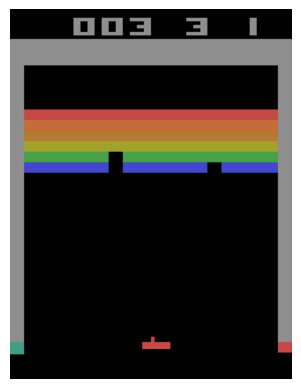

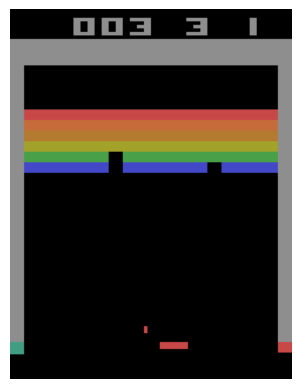

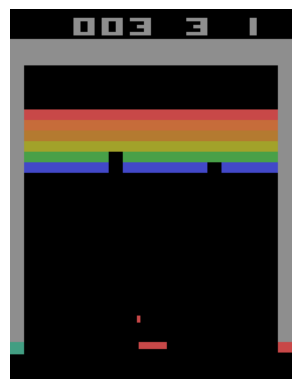

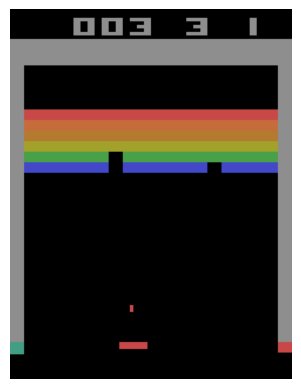

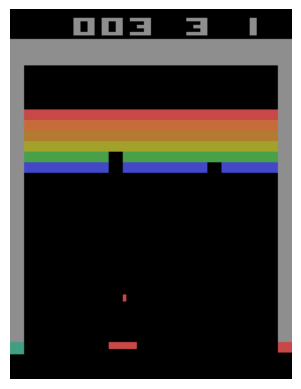

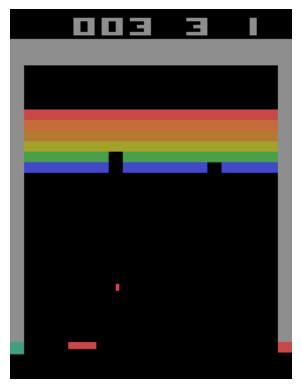

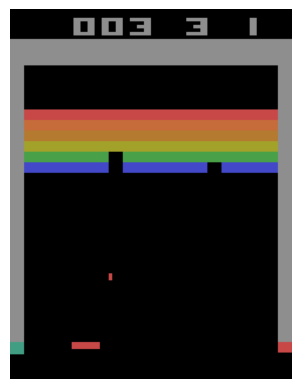

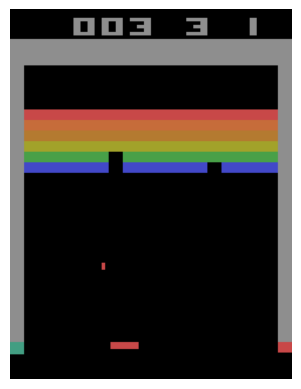

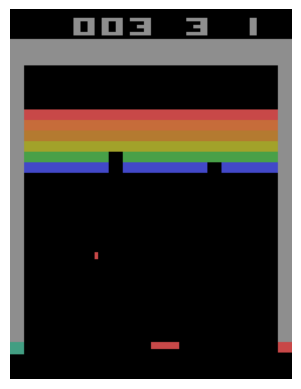

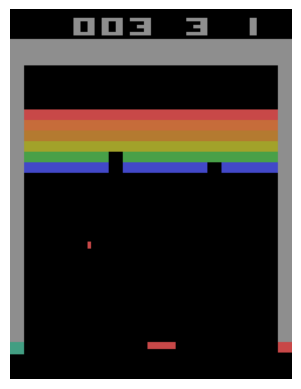

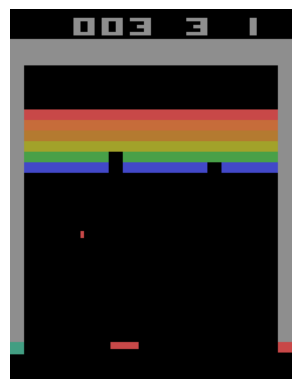

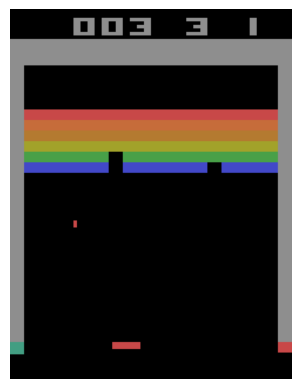

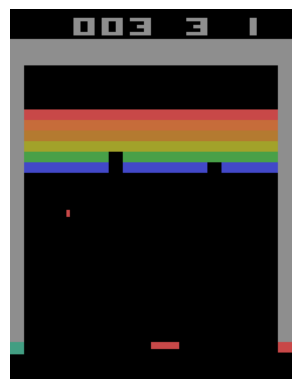

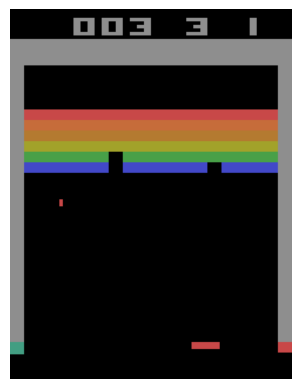

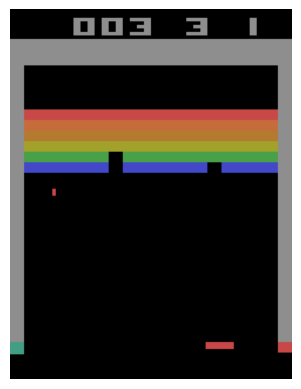

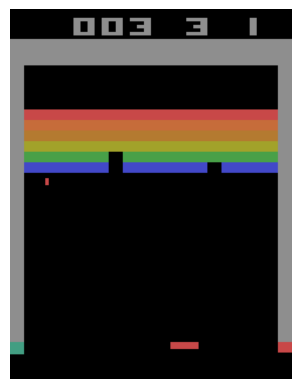

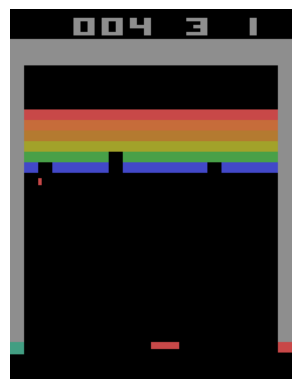

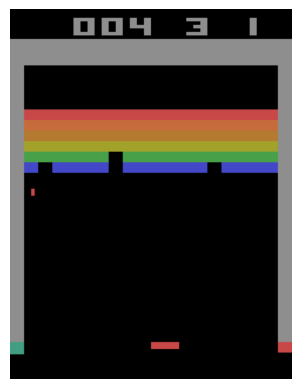

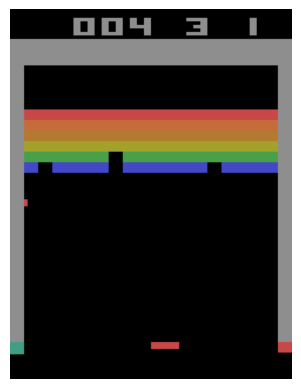

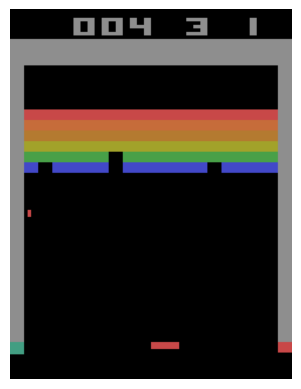

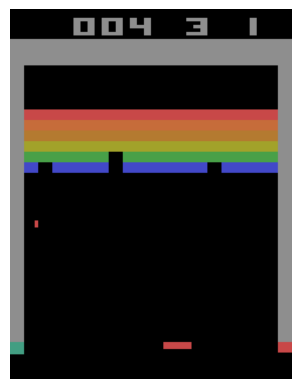

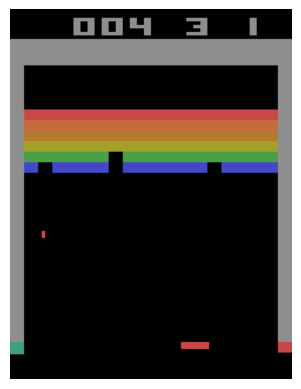

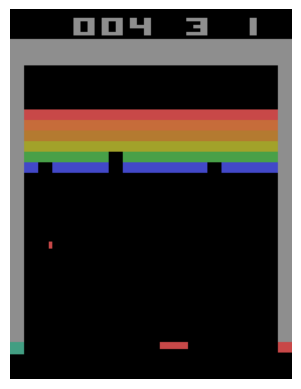

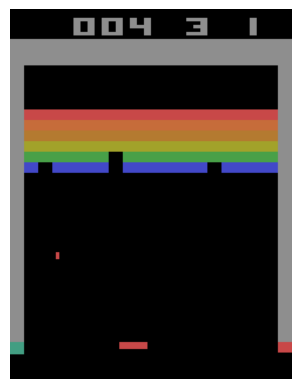

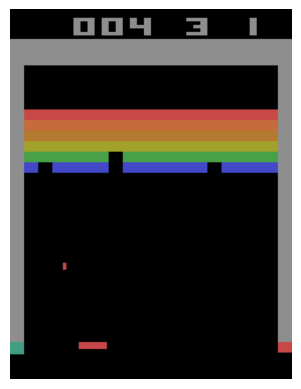

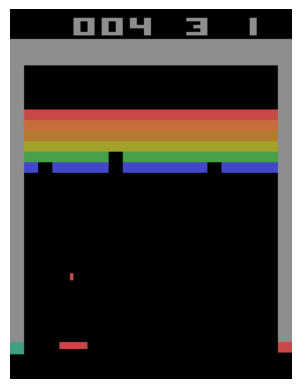

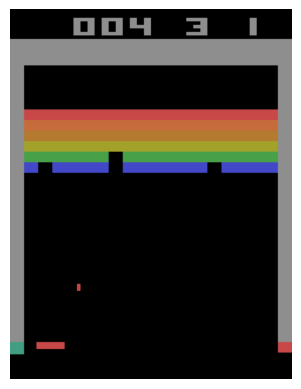

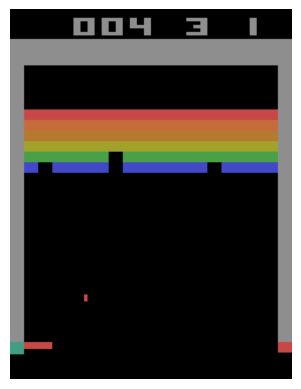

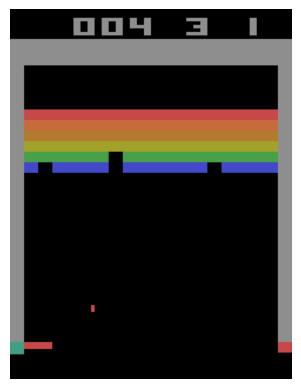

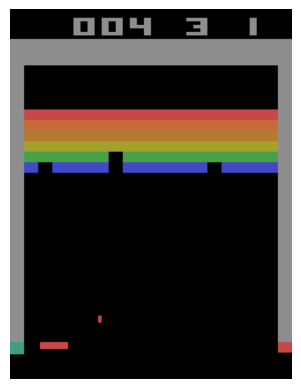

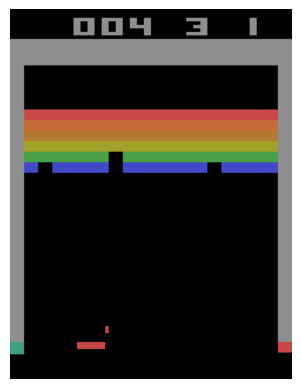

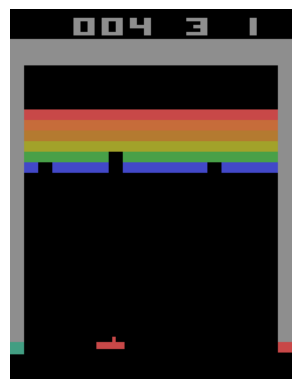

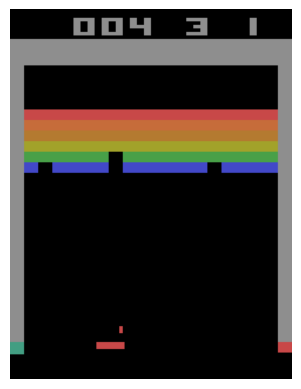

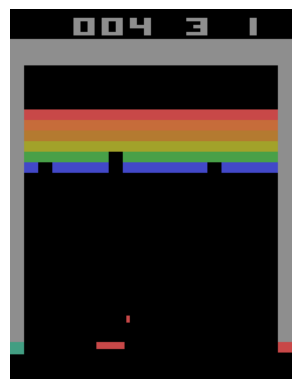

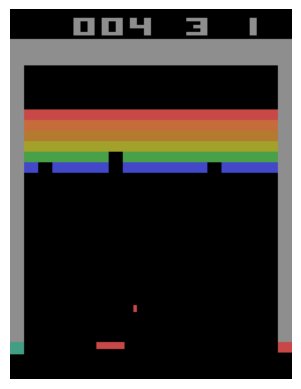

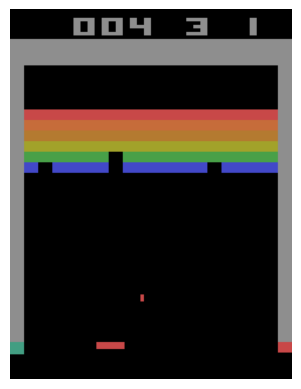

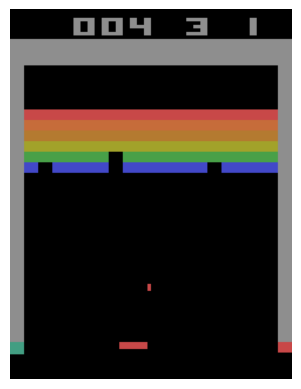

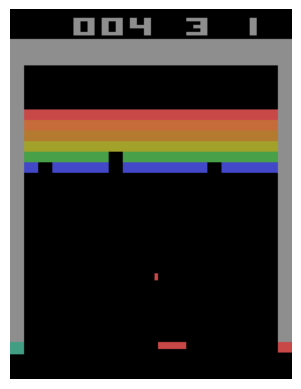

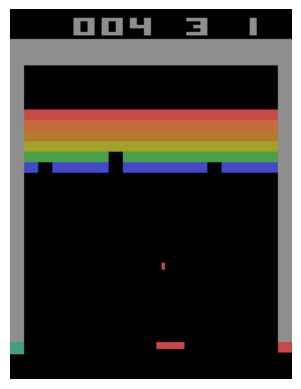

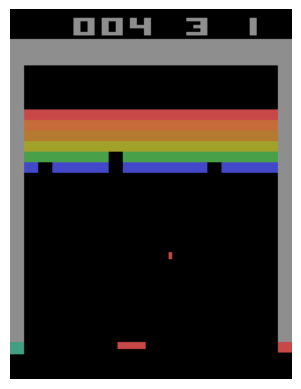

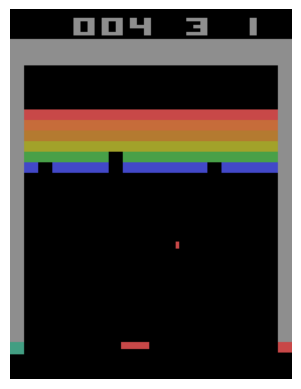

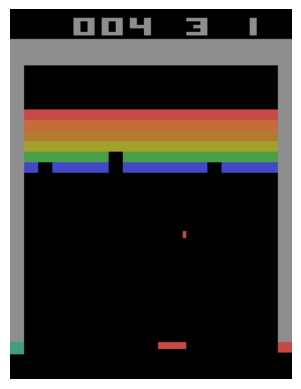

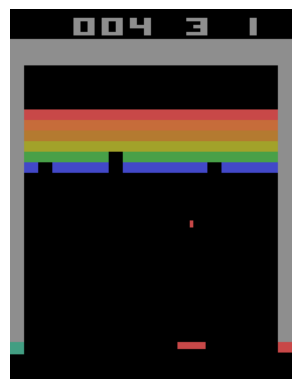

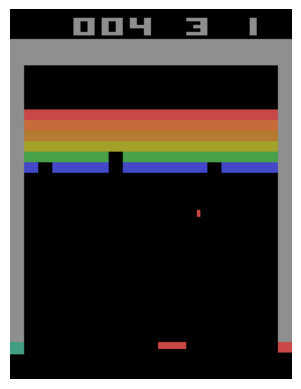

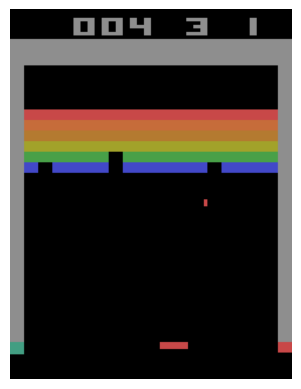

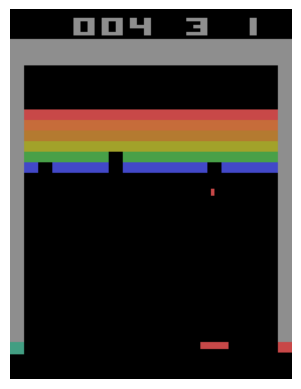

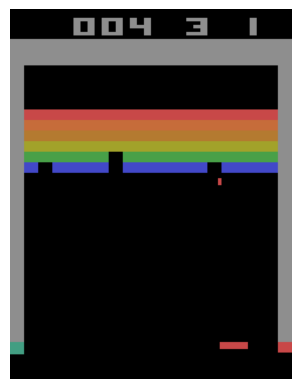

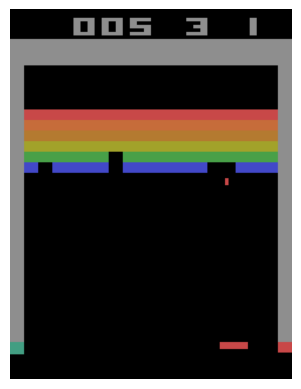

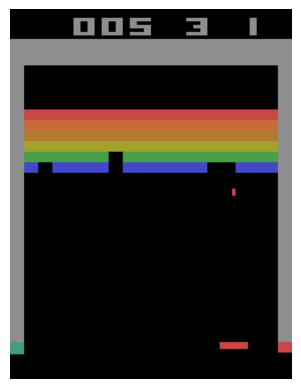

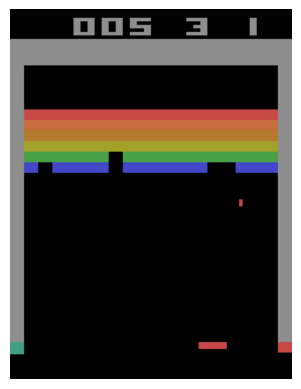

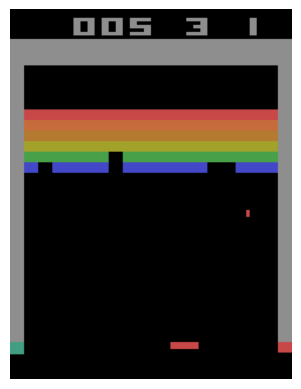

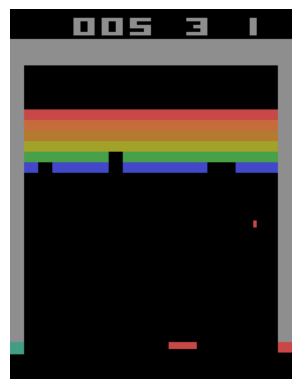

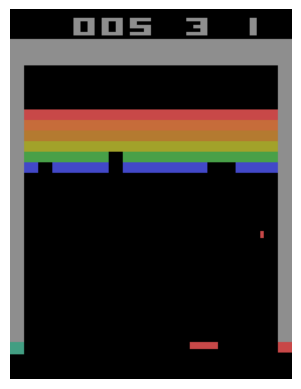

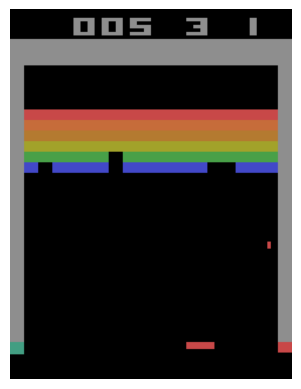

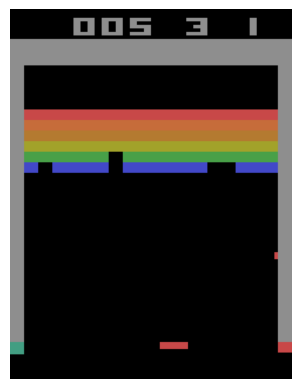

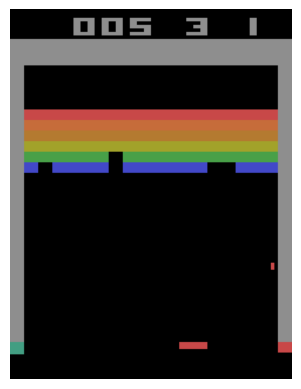

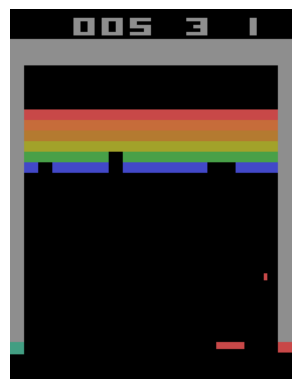

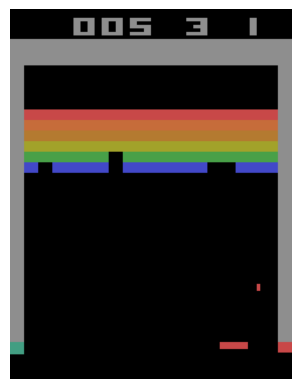

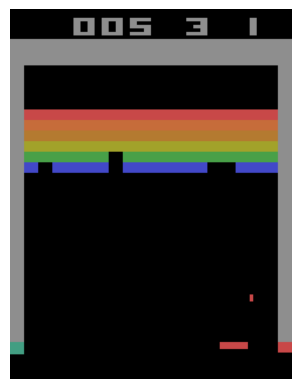

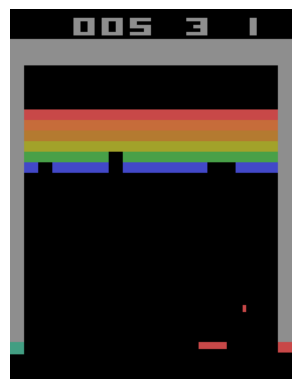

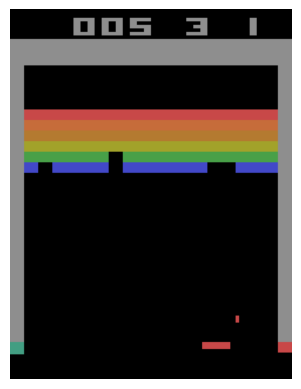

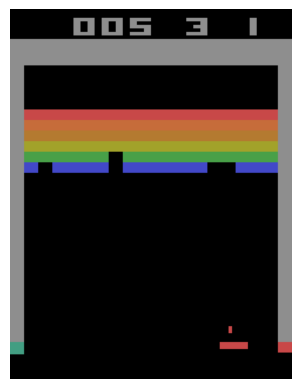

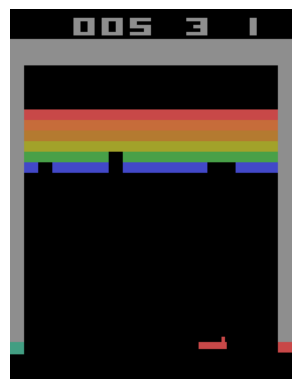

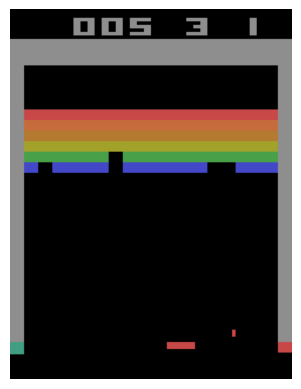

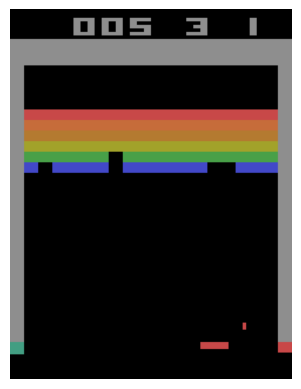

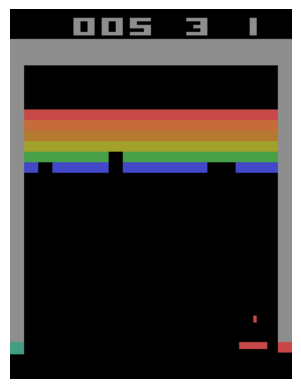

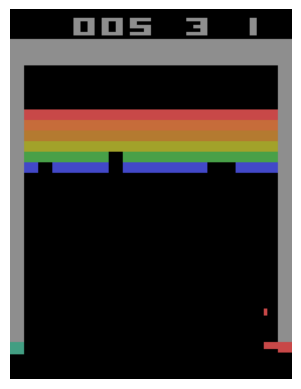

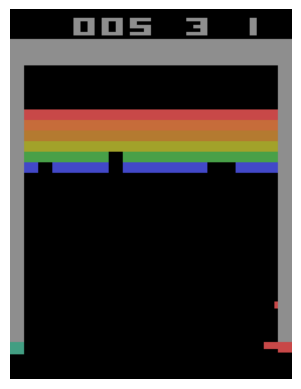

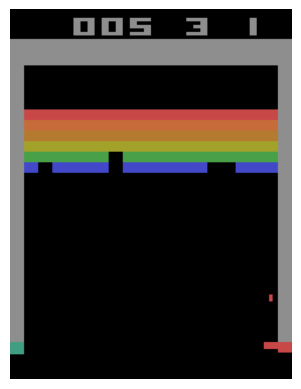

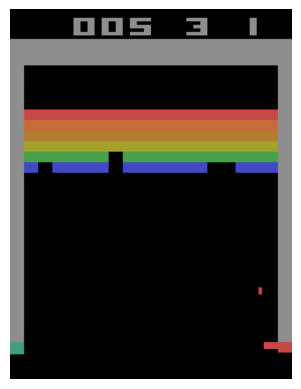

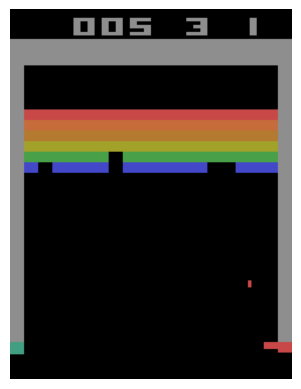

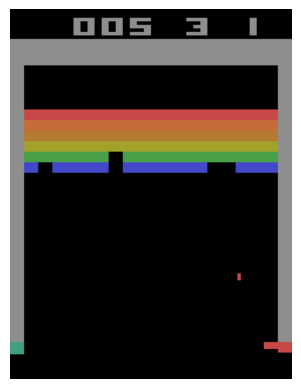

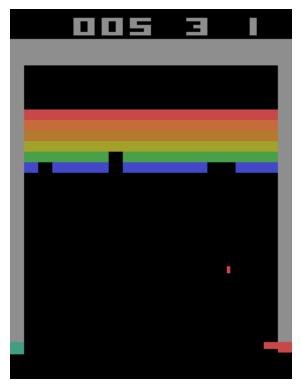

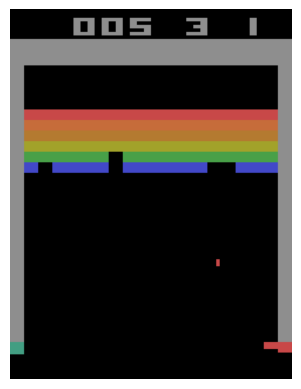

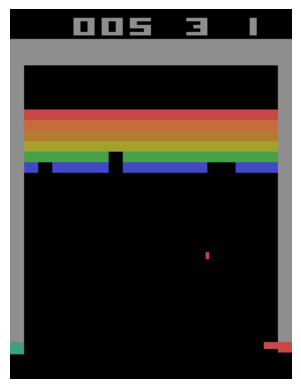

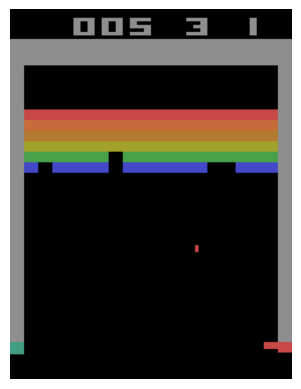

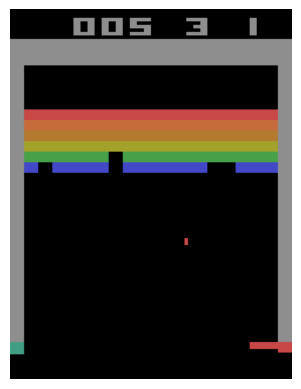

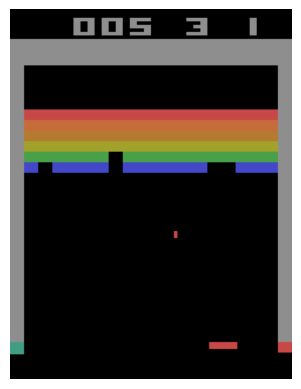

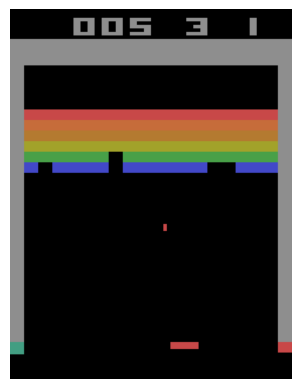

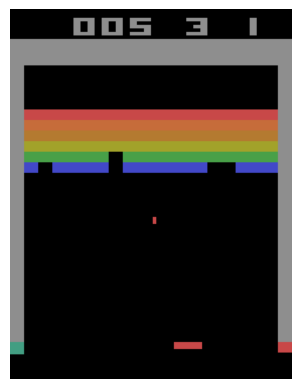

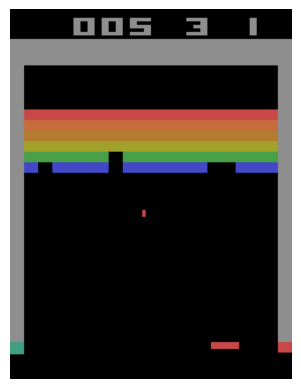

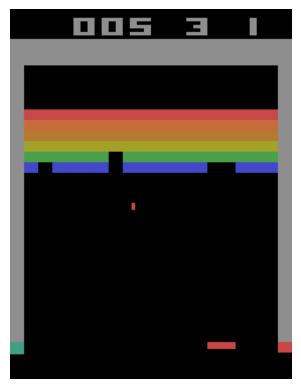

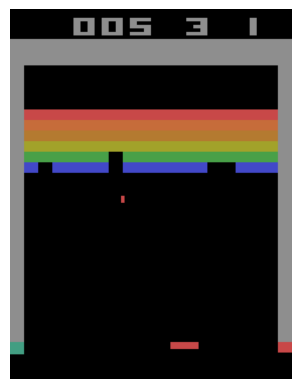

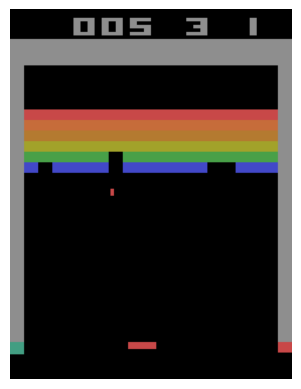

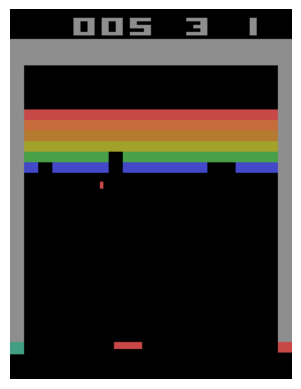

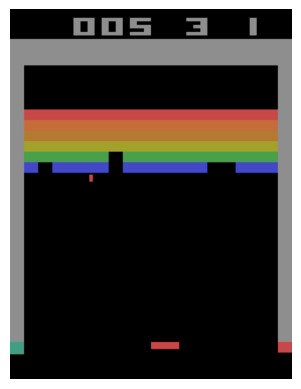

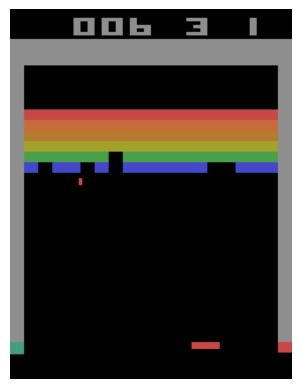

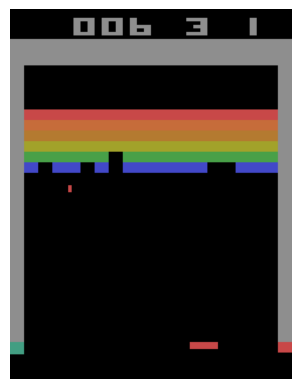

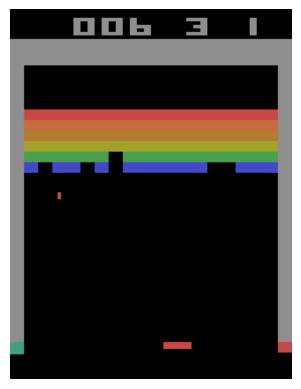

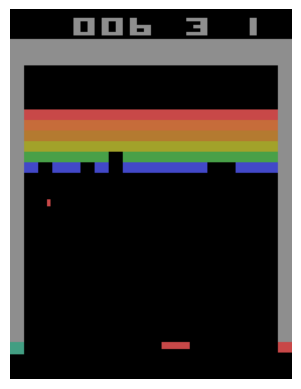

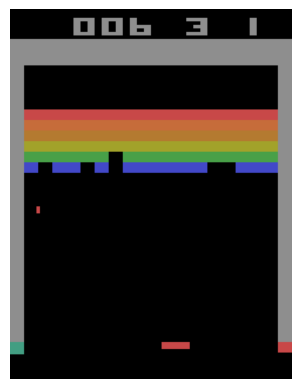

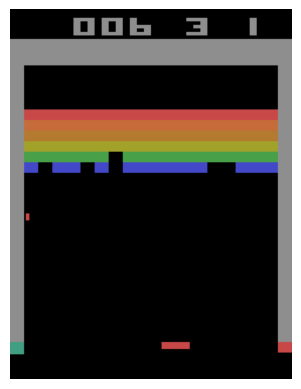

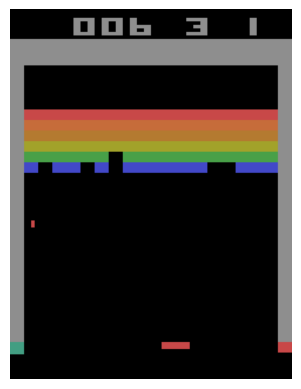

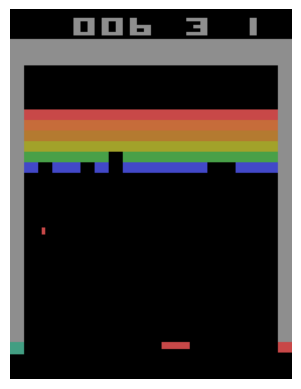

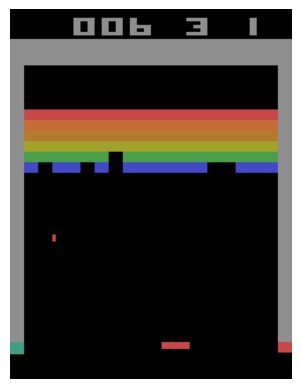

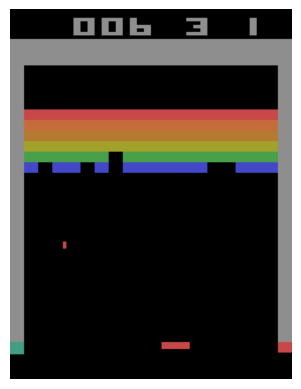

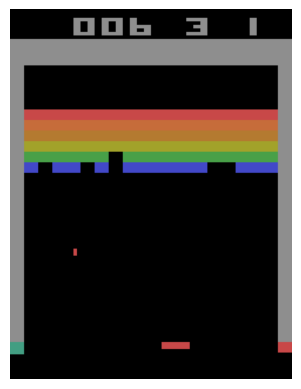

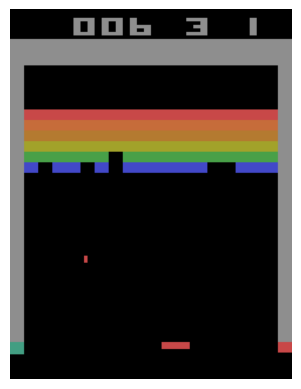

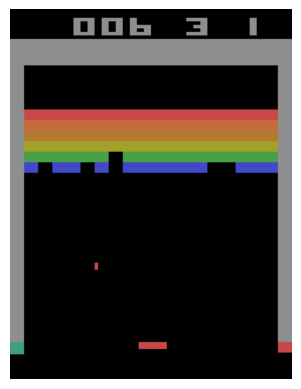

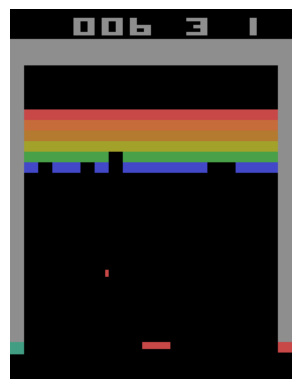

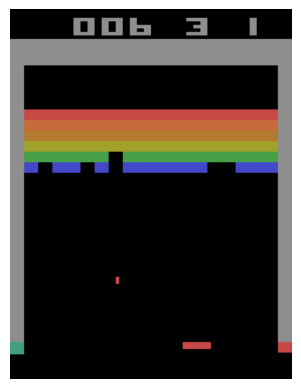

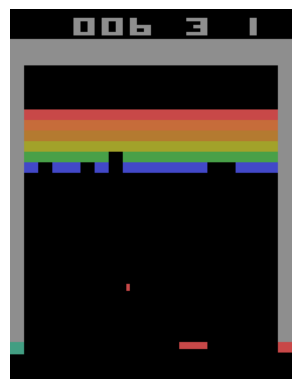

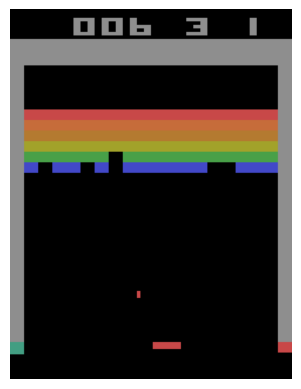

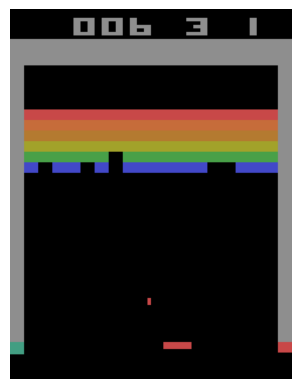

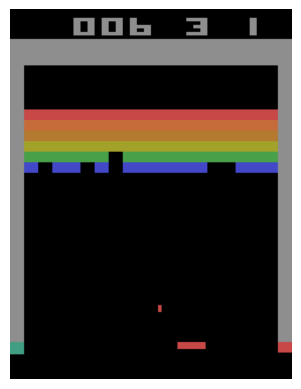

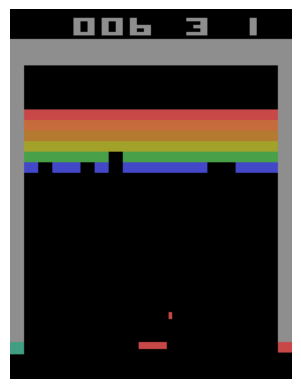

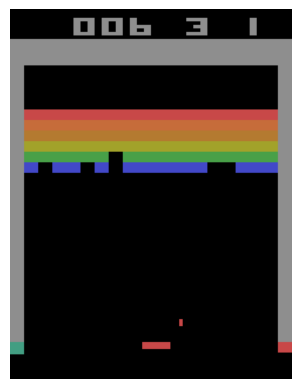

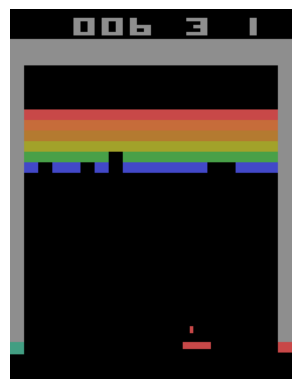

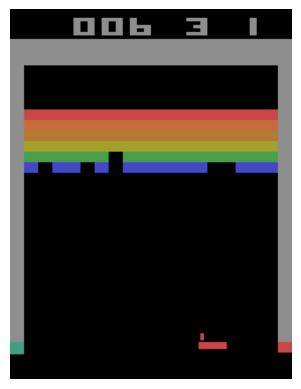

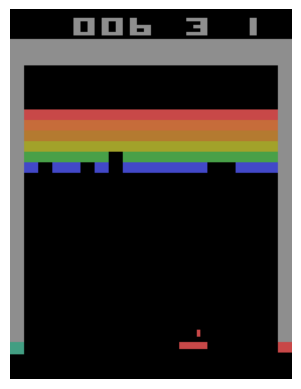

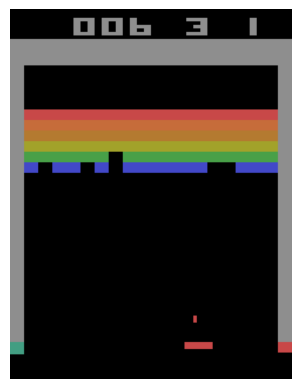

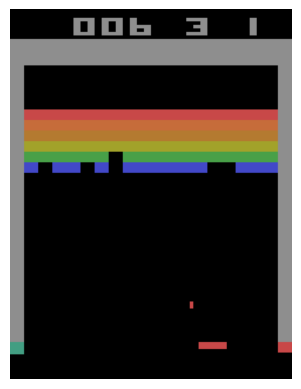

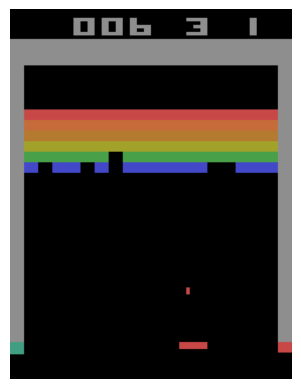

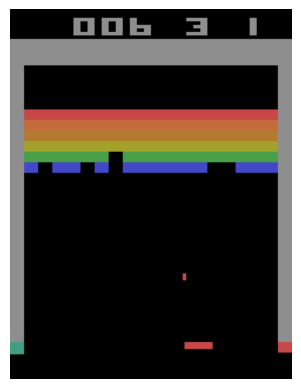

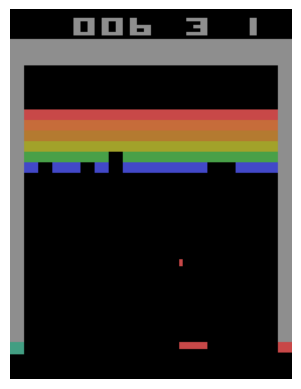

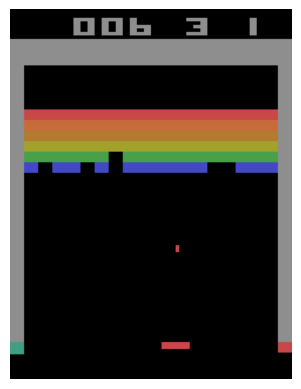

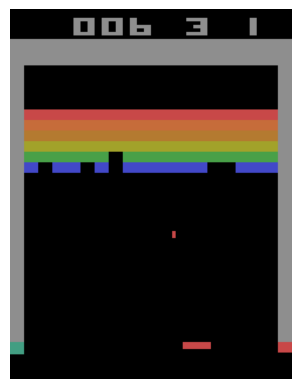

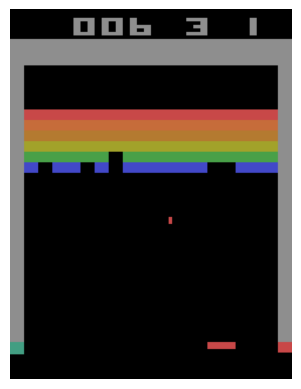

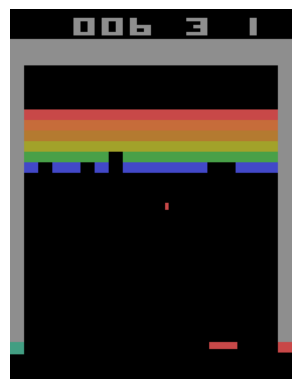

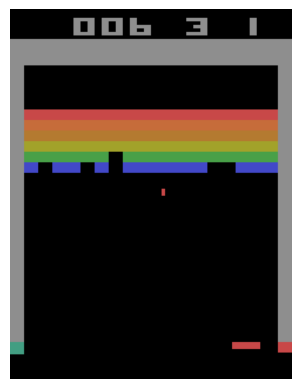

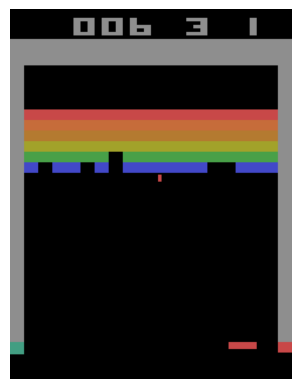

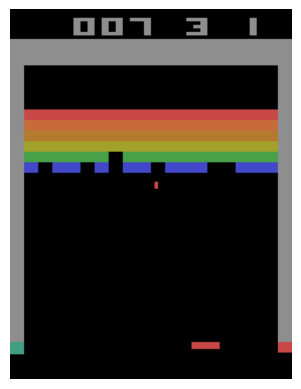

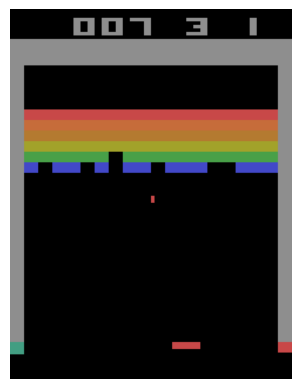

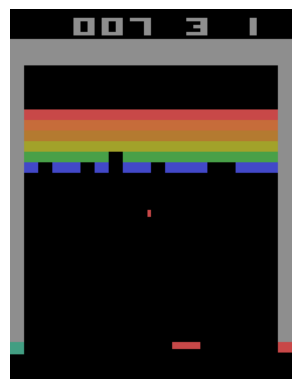

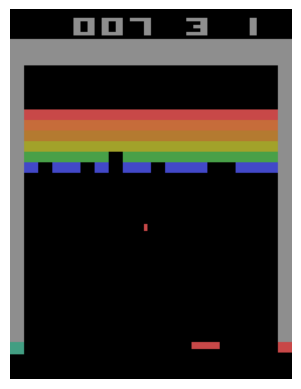

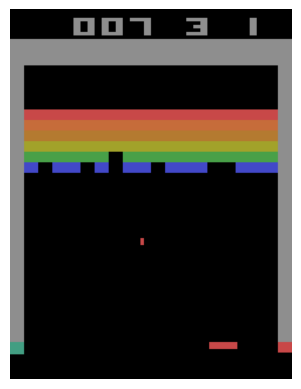

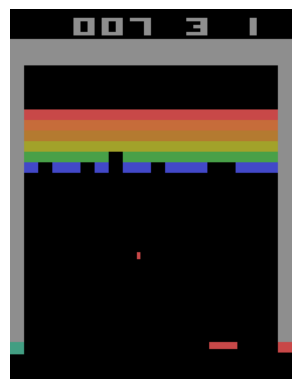

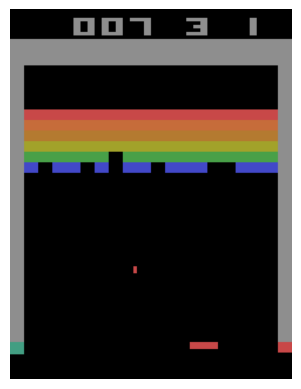

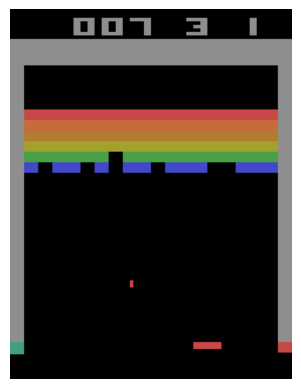

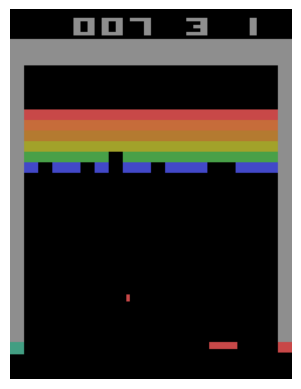

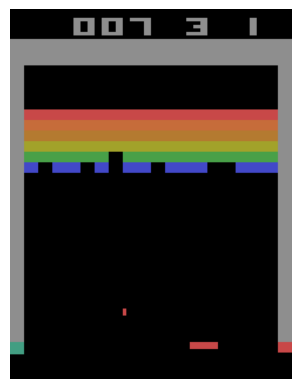

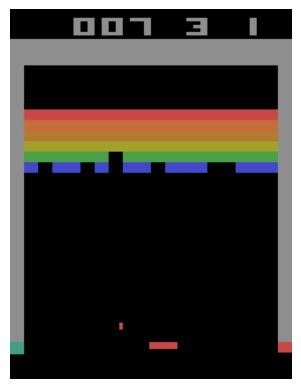

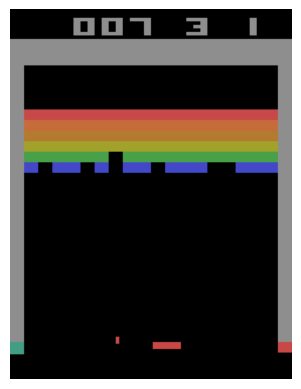

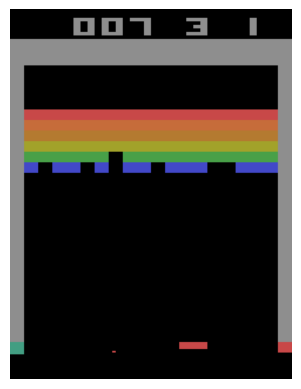

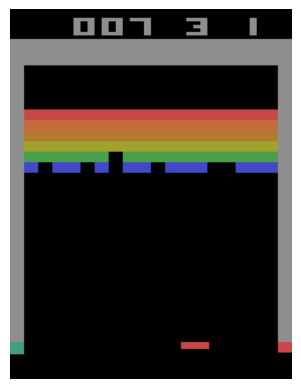

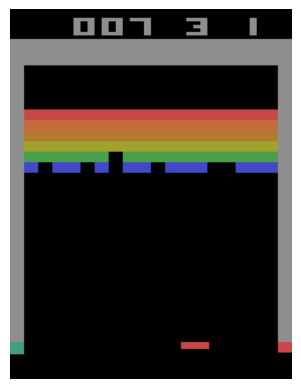

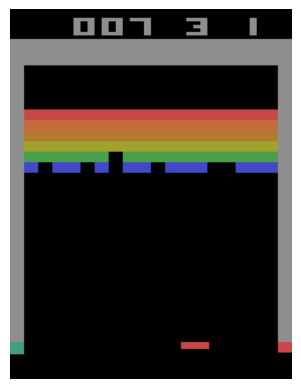

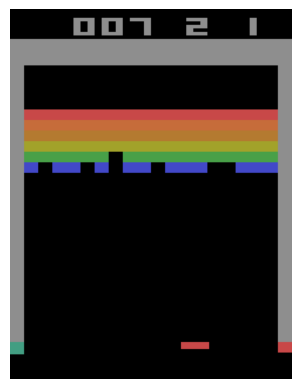

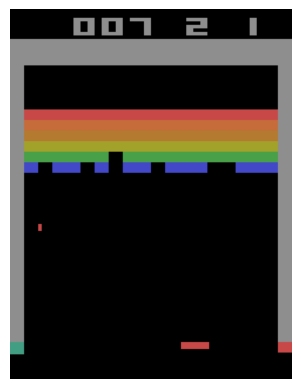

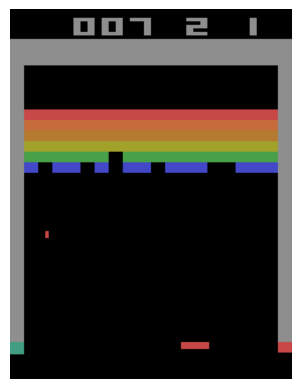

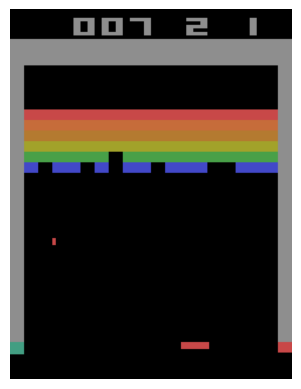

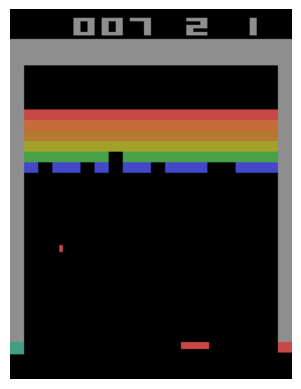

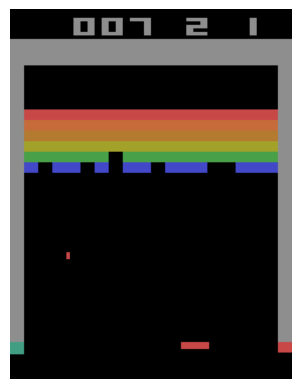

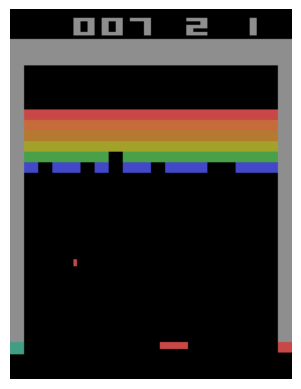

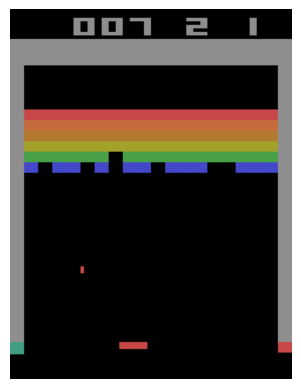

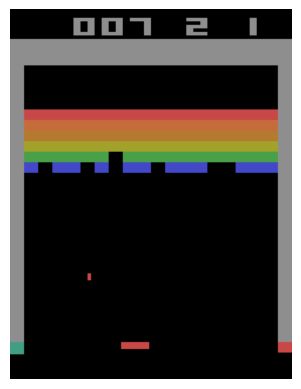

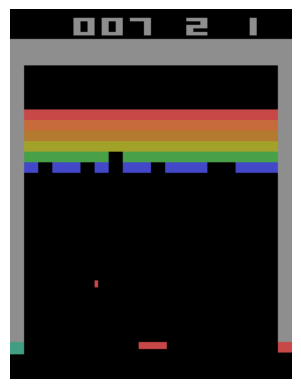

In [ ]:
import matplotlib.pyplot as plt

# Create new environment for rendering
test_env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
test_env = AtariPreprocessing(test_env)

state, _ = test_env.reset()

# FIRE action to start game
test_env.step(1)

for _ in range(300):
    with torch.no_grad():
        s = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        action = q_net(s).argmax().item()

    state, reward, done, truncated, _ = test_env.step(action)

    frame = test_env.env.render()

    plt.imshow(frame)
    plt.axis('off')
    plt.pause(0.01)

    if done or truncated:
        break

test_env.env.close()

In [ ]:
pip install imageio imageio-ffmpeg

In [ ]:
import imageio

video_filename = "breakout_dqn.mp4"
writer = imageio.get_writer(video_filename, fps=30)

test_env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
test_env = AtariPreprocessing(test_env)

state, _ = test_env.reset()
test_env.env.step(1)  # FIRE to start

for _ in range(500):
    with torch.no_grad():
        s = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        action = q_net(s).argmax().item()

    state, reward, done, truncated, _ = test_env.step(action)

    frame = test_env.env.render()
    writer.append_data(frame)

    if done or truncated:
        break

writer.close()
test_env.env.close()

print("✅ Video saved as:", video_filename)

✅ Video saved as: breakout_dqn.mp4
